In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')


In [44]:
FILE_PATH = "Data/consolidated_dataset.csv"

sns.set_style('darkgrid')
magma_palette = sns.color_palette('magma', 6)

try:
    df = pd.read_csv(FILE_PATH, index_col="Date", parse_dates=True)
    df.index.name = 'Date'
except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    exit()

print(f"Data loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Data loaded with 6277 rows and 54 columns.


# Exploratory Data Analysis

### Initial Data Inspection and Structure


In [45]:
print(f"Shape of data: {df.shape}")
print(f"Time range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
print("\nData Types and Non-Null Counts:")
df.info()
print("\nFirst 5 rows of the dataset:")
print(df.head().to_markdown())


Shape of data: (6277, 54)
Time range: 2015-01-01 to 2025-11-01

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6277 entries, 2015-01-01 to 2025-11-01
Data columns (total 54 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   adm1_name                                                             6277 non-null   object 
 1   adm2_name                                                             6277 non-null   object 
 2   mkt_name                                                              6277 non-null   object 
 3   c_maize_price                                                         6277 non-null   float64
 4   c_rice_price                                                          6277 non-null   float64
 5   c_sorghum_price                                                       6277 non-nu

## Data Cleaning and Preprocessing
This section addresses data quality issues, specifically missing values and outliers.


In [46]:
## Renaming Columns for Clarity
rename_map = {
    'c_maize_price': 'market_price_maize',
    'c_rice_price': 'market_price_rice',
    'c_sorghum_price': 'market_price_sorghum',
    'c_oil_price': 'market_price_oil',
    'c_food_price_index': 'food_price_index',

    'Population': 'population',

    'Climate_Temperature': 'climate_temperature',
    'Climate_Precipitation': 'climate_precipitation',
    'Climate_Humidity': 'climate_humidity',

    'Conflict_Critical': 'conflict_critical',
    'Conflict_Heightened': 'conflict_heightened',
    'Conflict_Typical': 'conflict_typical',

    'Drought_NDVI_Critical': 'drought_ndvi_critical',
    'Drought_NDVI_Heightened': 'drought_ndvi_heightened',
    'Drought_NDVI_Typical': 'drought_ndvi_typical',

    'Drought_rainfall_Critical': 'drought_rainfall_critical',
    'Drought_rainfall_Heightened': 'drought_rainfall_heightened',
    'Drought_rainfall_Typical': 'drought_rainfall_typical',

    'Exchange_rates_Critical': 'exchange_rate_critical',
    'Exchange_rates_Heightened': 'exchange_rate_heightened',
    'Exchange_rates_Typical': 'exchange_rate_typical',

    'Food_prices_Critical': 'food_price_critical',
    'Food_prices_Heightened': 'food_price_heightened',
    'Food_prices_Typical': 'food_price_typical',

    'Fuel_prices_Critical': 'fuel_price_critical',
    'Fuel_prices_Heightened': 'fuel_price_heightened',
    'Fuel_prices_Typical': 'fuel_price_typical',

    'GLM_Estimated_population_living_in_areas_at_risk':
        'risk_population_estimated',
    'GLM_Percentage_of_population_living_in_areas_at_risk':
        'risk_population_percentage',

    'Heavy_rainfall_Critical': 'heavy_rainfall_critical',
    'Heavy_rainfall_Heightened': 'heavy_rainfall_heightened',
    'Heavy_rainfall_Typical': 'heavy_rainfall_typical',

    'ALL_GROUPS': 
        'cpi_all_groups',
    'ALCOHOLIC_BEVERAGES_TOBACCO_AND_NARCOTICS':
        'cpi_alcohol_tobacco_narcotics',
    'CLOTHING_AND_FOOTWEAR':
        'cpi_clothing_footwear',
    'COMMUNICATION':
        'cpi_communication',
    'EDUCATION':
        'cpi_education',
    'FOOD_AND_NON_ALCOHOLIC_BEVERAGES':
        'cpi_food_non_alcoholic_beverages',
    'FURNISHINGS_HOUSEHOLD_EQUIPMENT_AND_ROUTINE_MAINTENANCE_OF_THE_HOUSE':
        'cpi_furnishings_household_maintenance',
    'HEALTH':
        'cpi_health',
    'HOUSING_WATER_ELECTRICITY_GAS_AND_OTHER_FUELS':
        'cpi_housing_utilities',
    'MISCELLANEOUS_GOODS_AND_SERVICES':
        'cpi_miscellaneous',
    'RECREATION_AND_CULTURE':
        'cpi_recreation_culture',
    'RESTAURANTS_AND_HOTELS':
        'cpi_restaurants_hotels',
    'TRANSPORT':
        'cpi_transport',

    'Exchange_Rate': 'exchange_rate',
    'GDP_per_capita,_US_Dollars': 'gdp_per_capita_usd',
    'Government_final_consumption': 'government_final_consumption',
    'Gross_fixed_capital_formation': 'gross_fixed_capital_formation',
    'Household_final_consumption': 'household_final_consumption',
    'Minus:_Imports_of_goods_and_services': 'imports_goods_services'
}
    
df = df.rename(columns=rename_map)
TARGET_VARIABLE = 'food_price_index'

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

### Missing Data Strategy
The high granularity of the data results in significant missingness, particularly in localized shock variables and macroeconomic indicators. A robust strategy is required to handle this without introducing bias.


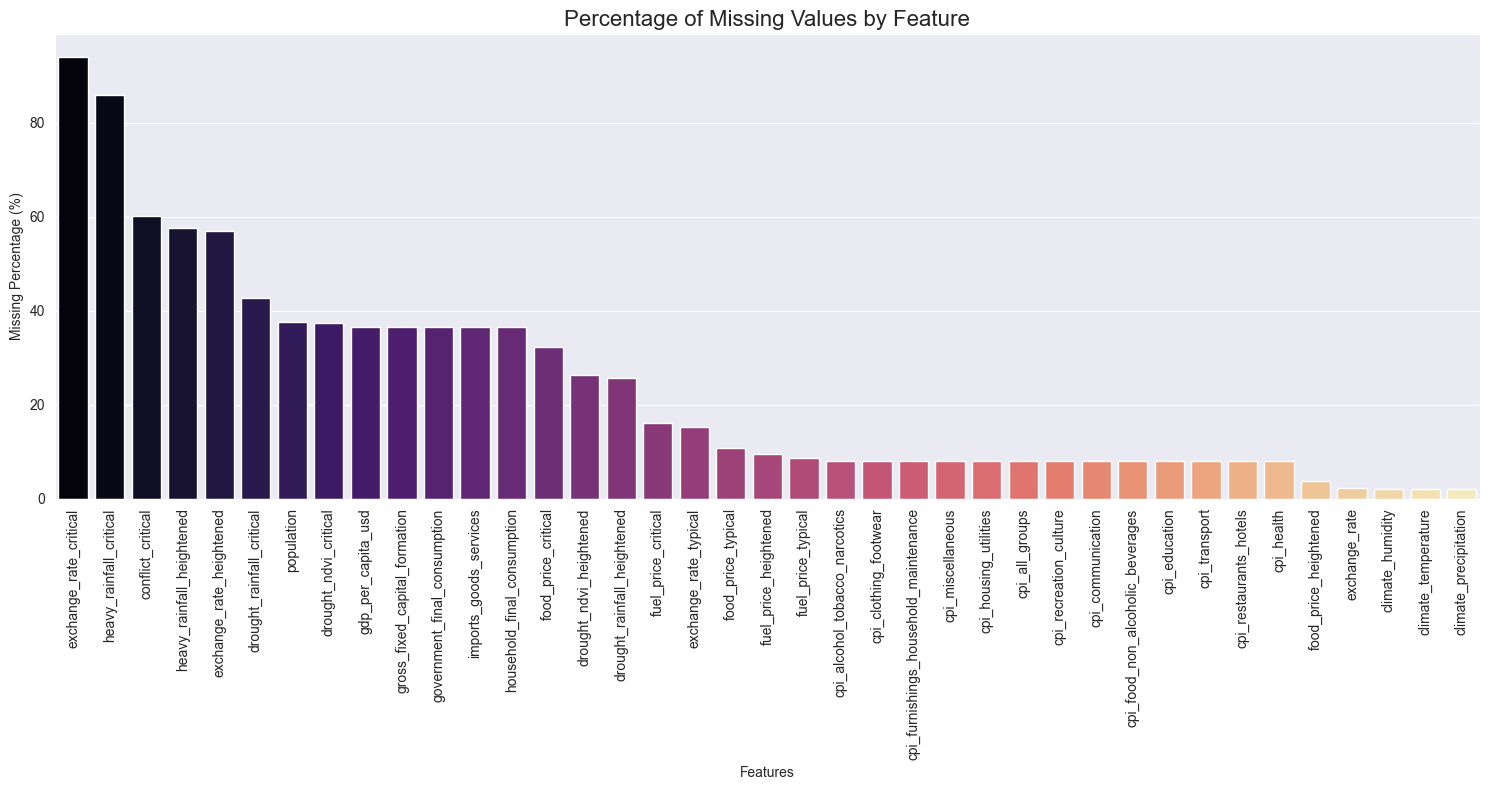

In [47]:
# Calculate missing value percentage
missing_perc = df.isnull().sum() / len(df) * 100
missing_perc = missing_perc[missing_perc > 0].sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=missing_perc.index, y=missing_perc.values, palette='magma')
plt.title('Percentage of Missing Values by Feature', fontsize=16)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The missing data plot confirms that many features have substantial missing values. The strategy for imputation will be: 

*   **Localized Shocks (Conflict, Drought, Heavy Rainfall):** Missing values likely mean the event was **not critical/heightened/typical** in that specific region/month. These will be imputed with **0** (or a baseline value) to reflect the absence of the event. 

*   **Price and Climate Variables:** These are time-series data. Missing values will be handled using **forward-fill (`ffill`)** followed by **backward-fill (`bfill`)** to maintain temporal continuity. 

*   **Macroeconomic Variables (GDP, Consumption):** These are often reported quarterly or annually. They will be handled with `ffill`/`bfill` after grouping by the regional identifier to ensure the most recent available value is used for the region.


In [49]:
shock_cols = [col for col in df.columns if any(s in col for s in ['conflict', 'drought', 'heavy_rainfall', 'food_price', 'Fuel_price', 'exchange_rate'])]
price_climate_cols = [col for col in df.columns if any(s in col for s in ['price', 'climate', 'exchange_rate']) and col not in shock_cols]
macro_cols = [col for col in df.columns if any(s in col for s in ['gdp', 'consumption', 'fixed_capital', 'imports']) and col not in shock_cols]

df[shock_cols] = df[shock_cols].fillna(0)
df[price_climate_cols] = df[price_climate_cols].fillna(method='ffill').fillna(method='bfill')
for col in macro_cols:
    df[col] = df.groupby('adm1_name')[col].fillna(method='ffill').fillna(method='bfill')

print("Missing data imputation complete. Checking remaining nulls:")
print(df.isnull().sum().sort_values(ascending=False).head().to_markdown())


Missing data imputation complete. Checking remaining nulls:
|                                       |    0 |
|:--------------------------------------|-----:|
| population                            | 2364 |
| cpi_furnishings_household_maintenance |  499 |
| cpi_health                            |  499 |
| cpi_all_groups                        |  499 |
| cpi_alcohol_tobacco_narcotics         |  499 |


In [50]:
# Imputation of Remaining Missing Values
df['population'] = df.groupby(['adm1_name', 'adm2_name'])['population'].ffill().bfill()

# 2. Handle Consumption Categories - Missing at end of time series, hence will be dropped
consumption_cols_to_check = [
    'cpi_furnishings_household_maintenance',
    'cpi_health',
    'cpi_all_groups',
    'cpi_alcohol_tobacco_narcotics'
]

rows_before_drop = df.shape[0]
df.dropna(subset=consumption_cols_to_check, inplace=True)
rows_after_drop = df.shape[0]

print(f"Dropped {rows_before_drop - rows_after_drop} rows with missing consumption data.")
print(f"New DataFrame shape: {df.shape}")

print("\nFinal check of missing values in imputed columns:")
final_nulls = df[['population'] + consumption_cols_to_check].isnull().sum()
print(final_nulls.to_markdown())


Dropped 499 rows with missing consumption data.
New DataFrame shape: (5778, 54)

Final check of missing values in imputed columns:
|                                       |   0 |
|:--------------------------------------|----:|
| population                            |   0 |
| cpi_furnishings_household_maintenance |   0 |
| cpi_health                            |   0 |
| cpi_all_groups                        |   0 |
| cpi_alcohol_tobacco_narcotics         |   0 |


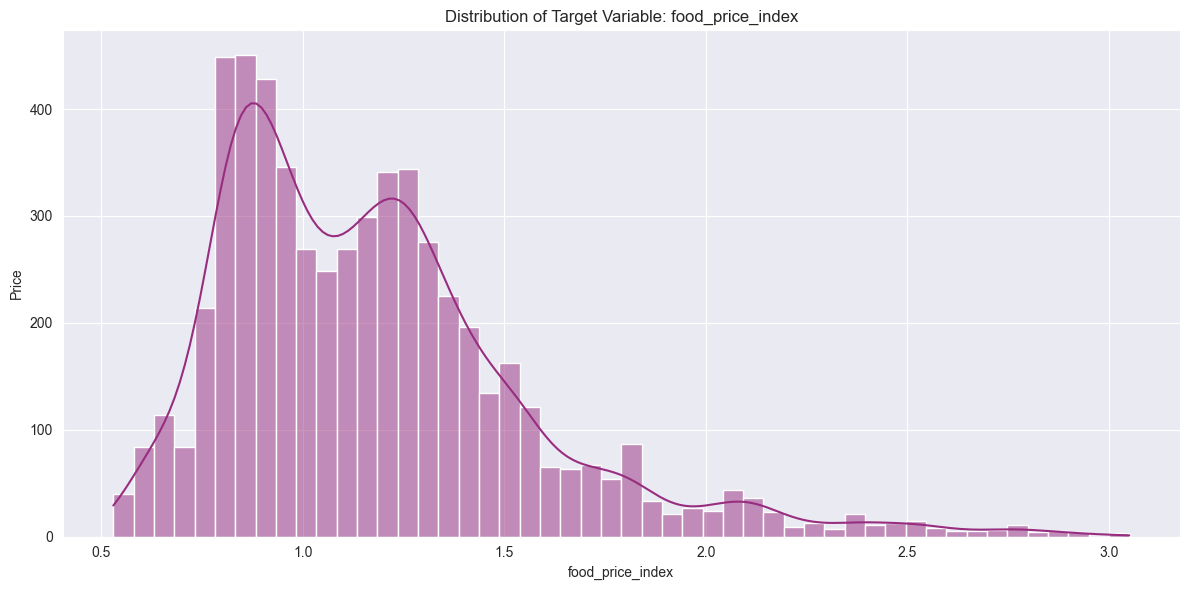

In [51]:
plt.figure(figsize=(12, 6))
sns.histplot(df[TARGET_VARIABLE].dropna(), kde=True, color=magma_palette[2])
plt.title(f'Distribution of Target Variable: {TARGET_VARIABLE}')
plt.ylabel('Price')
plt.tight_layout()

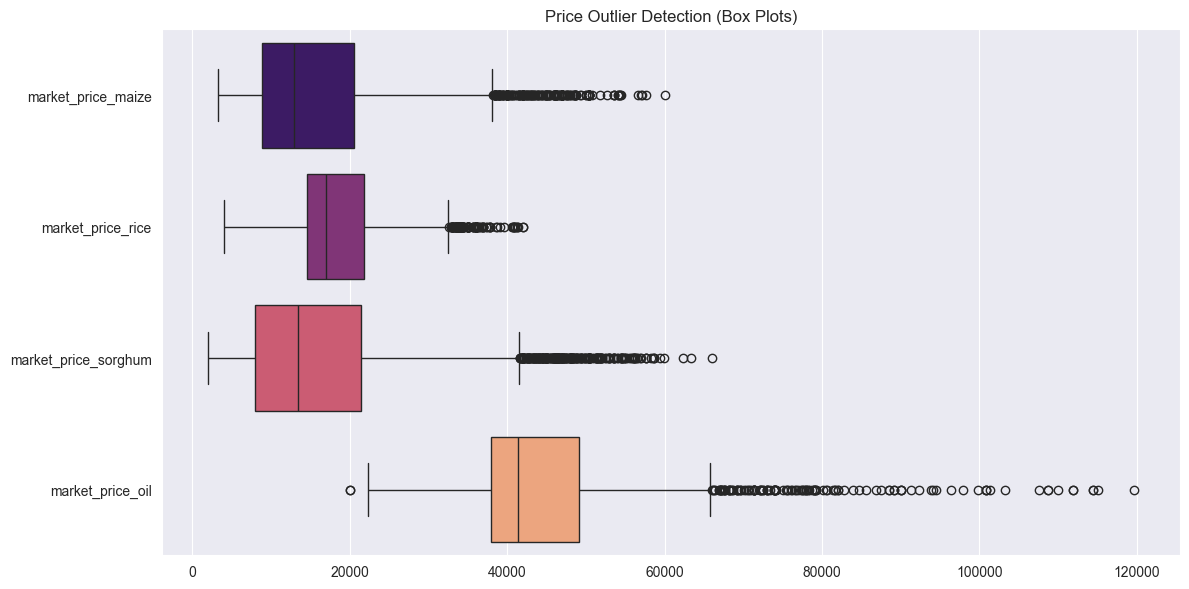

In [52]:
price_vars =['market_price_maize', 'market_price_rice', 'market_price_sorghum', 'market_price_oil']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[price_vars], orient="h", palette="magma")
plt.title('Price Outlier Detection (Box Plots)')
plt.tight_layout()

The box plots clearly show the presence of **significant outliers** in all price series. These outliers could be due to extreme market events (e.g., severe drought, conflict spikes) or data entry errors.

* Given the time-series nature, simply removing these outliers might distort the underlying economic reality. A common approach is to use a **robust scaler** (like the `RobustScaler` in scikit-learn) or to **winsorize** the data (cap the extreme values) during the preprocessing phase for model training.


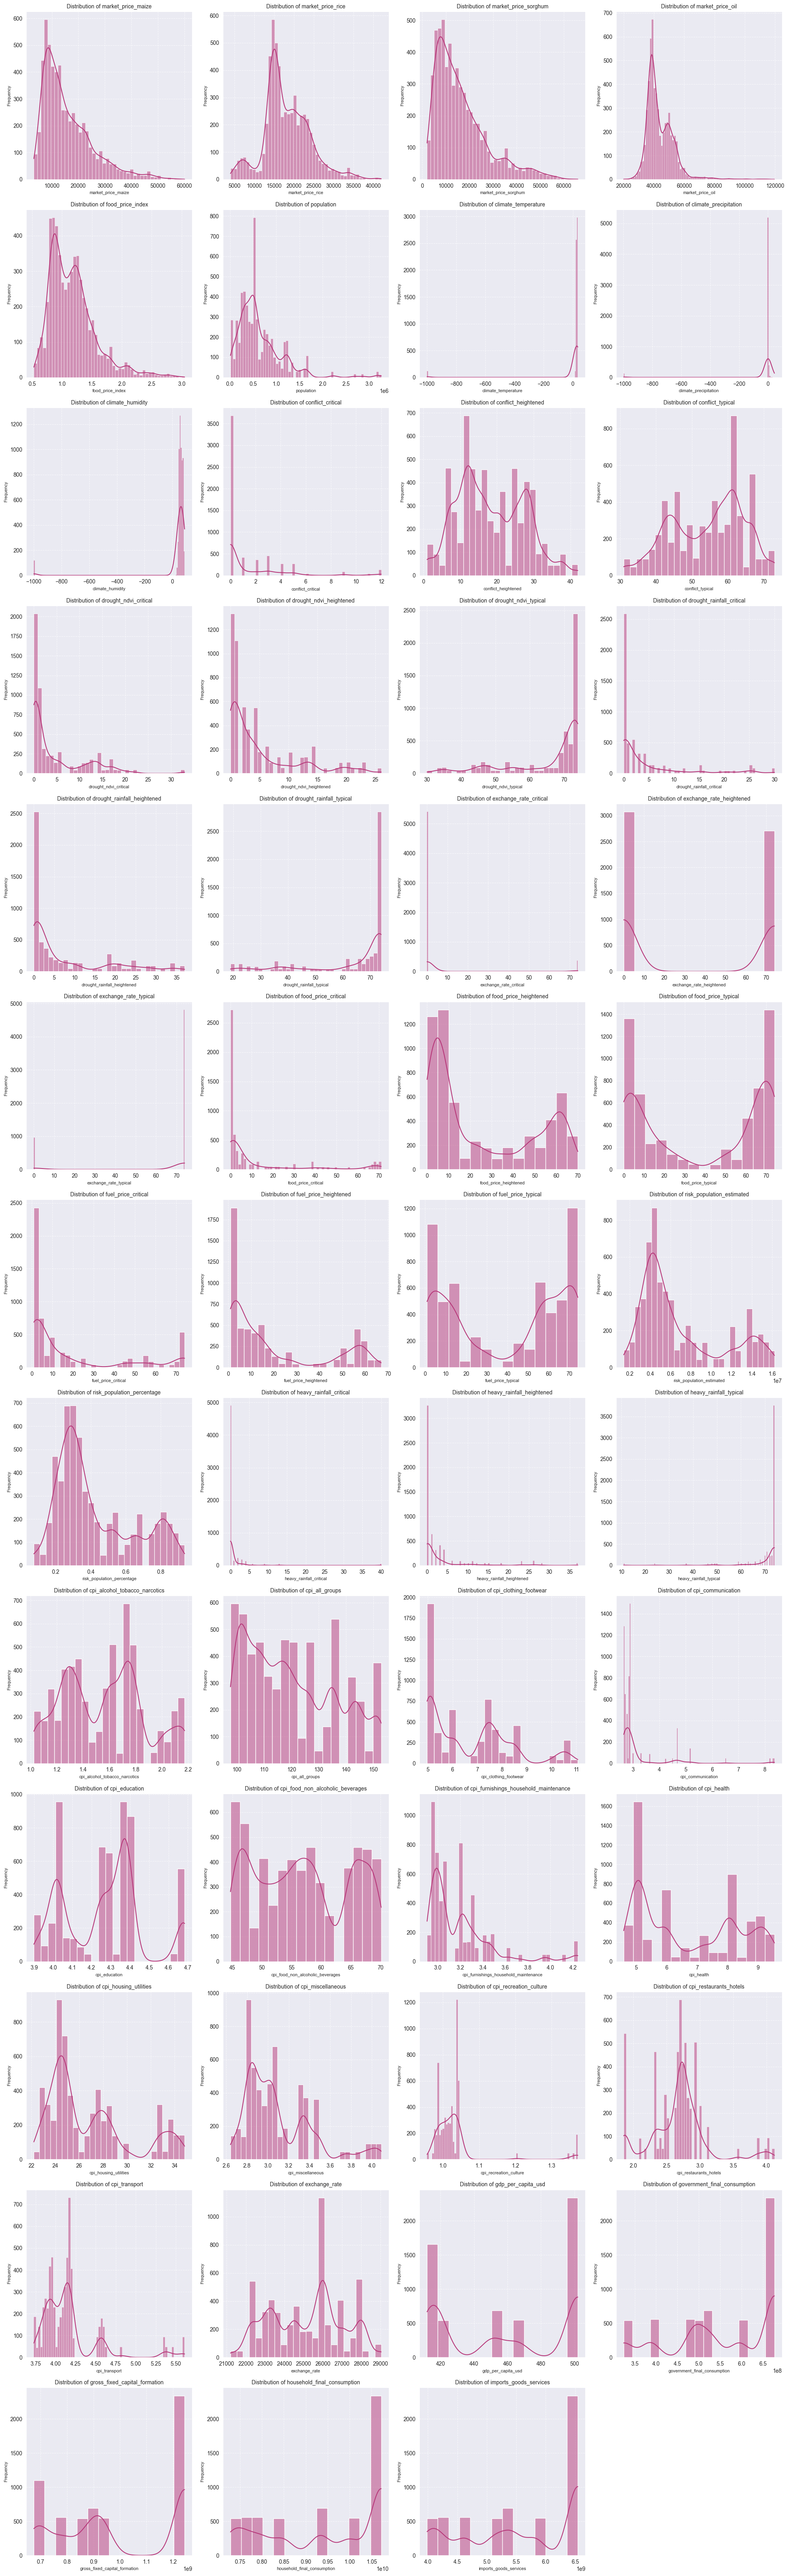

In [53]:
magma_colors = sns.color_palette('magma', 3)
n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=magma_colors[1])
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


The price distributions generally exhibit a **right-skewed** pattern, which is common for commodity prices, indicating a long tail of higher-than-average prices. This skewness suggests that standard linear models might benefit from a log transformation of these variables.

The Climate columns have clear outliers. Further inspection revealed that some rows had values -999

In [54]:
climate_cols = [
    'climate_temperature',
    'climate_precipitation',
    'climate_humidity',
]

df[climate_cols] = df[climate_cols].replace(-999, np.nan)

### Outlier Detection and Handling
We mitigate the influence of outliers by applying region-wise outlier capping using robust quantile thresholds, following domain-based cleaning to remove implausible values. Binary and categorical shock indicators are excluded from this process.


Outlier capping applied to 51 columns, grouped by region.


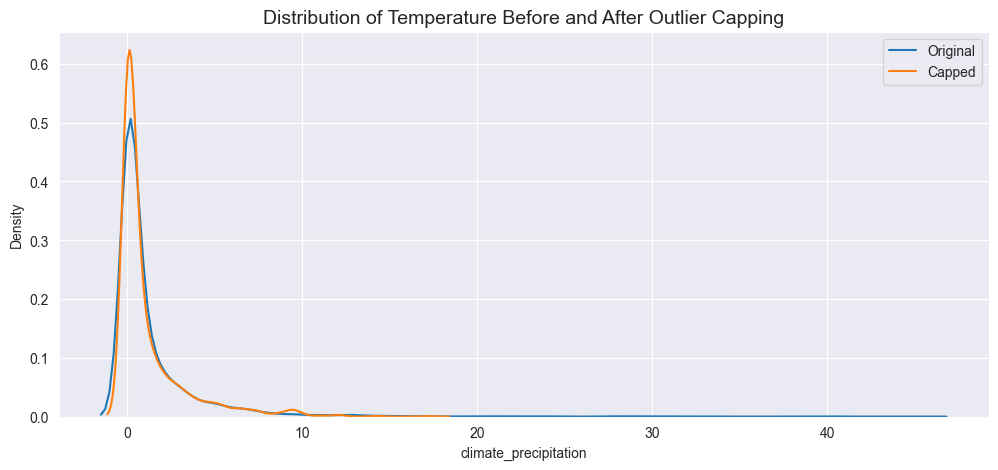

In [55]:
def cap_outliers_mean_std(series, threshold=3):
    mean = series.mean()
    std = series.std()

    upper_bound = mean + threshold * std
    lower_bound = mean - threshold * std

    return series.clip(lower=lower_bound, upper=upper_bound)

df_pre_outlier = df[numerical_cols].copy()

for col in numerical_cols:
    df[col] = (
        df.groupby('adm1_name')[col]
          .transform(lambda x: cap_outliers_mean_std(x, threshold=3))
    )

print(f"Outlier capping applied to {len(numerical_cols)} columns, grouped by region.")

plt.figure(figsize=(12, 5))
sns.kdeplot(
    df_pre_outlier['climate_precipitation'].dropna(),
    label='Original'
)
sns.kdeplot(
    df['climate_precipitation'].dropna(),
    label='Capped'
)
plt.title('Distribution of Temperature Before and After Outlier Capping', fontsize=14)
plt.legend()
plt.show()


The capping process, applied on a regional basis, has successfully reduced the influence of extreme values in the target variable, leading to a more normalized distribution. This approach preserves the majority of the data while mitigating the risk of a few extreme points disproportionately influencing the model.


## Univariate Analysis
We examine the distribution and temporal characteristics of the key variables, focusing on the target.


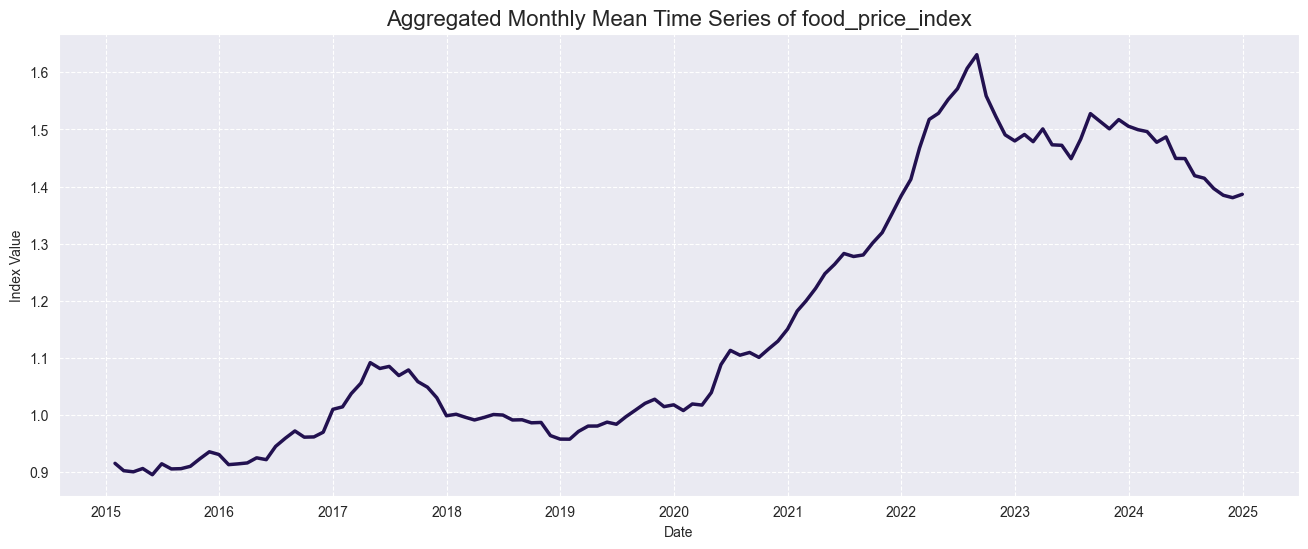

In [56]:
# Target Variable Time Series (Aggregated)
plt.figure(figsize=(16, 6))
df_monthly_mean = df.select_dtypes(include=np.number).resample('M').mean()
sns.lineplot(data=df_monthly_mean[TARGET_VARIABLE], color=magma_palette[0], linewidth=2.5)
plt.title(f'Aggregated Monthly Mean Time Series of {TARGET_VARIABLE}', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid(True, linestyle='--')
plt.show()


#### Target Variable Trend
The time series plot for the aggregated Food Price Index shows a clear, non-stationary upward trend, especially in the later years. This suggests that the model will need to account for this trend, potentially through differencing or by including time-based features.


## Bivariate and Multivariate Analysis
This section explores the relationships between the target variable and the predictors, including regional and time-based interactions.


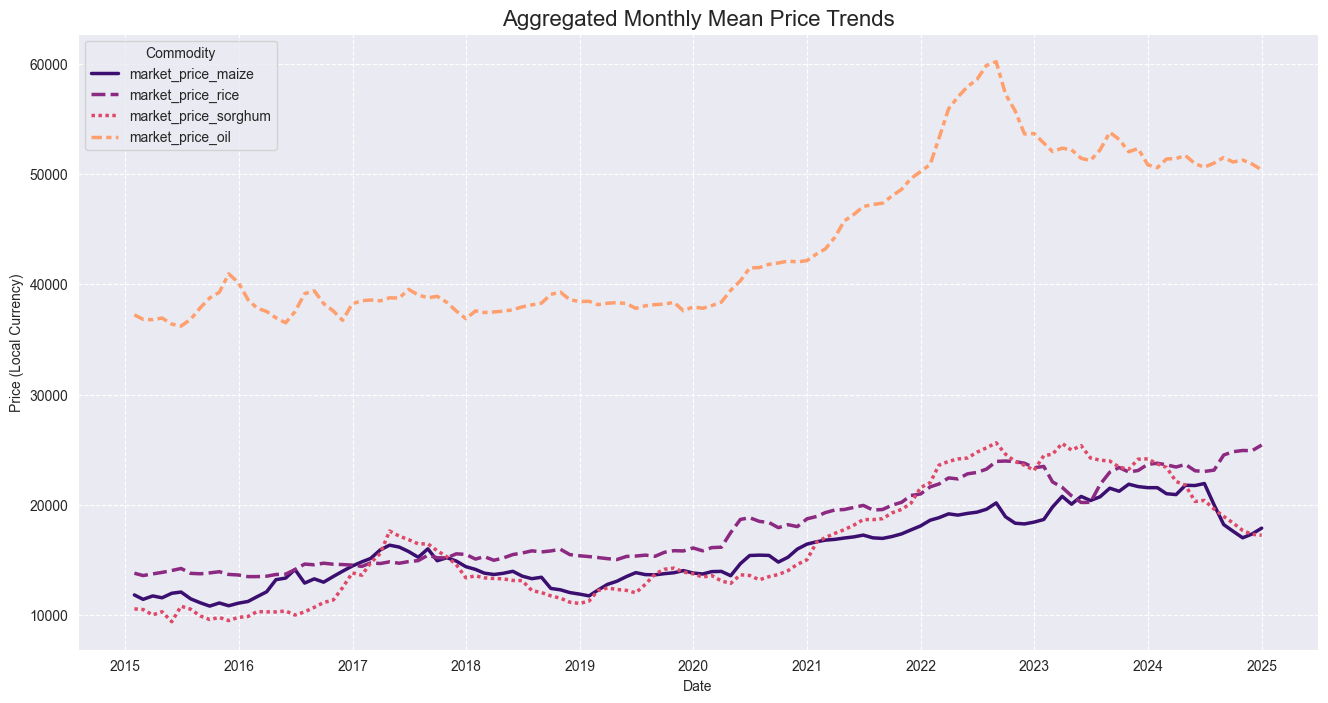

In [57]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df_monthly_mean[price_vars], palette='magma', linewidth=2.5)
plt.title('Aggregated Monthly Mean Price Trends', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (Local Currency)')
plt.legend(title='Commodity')
plt.grid(True, linestyle='--')
plt.show()


#### Commodity Price Co-movement
The inclusion of sorghum price confirms a strong co-movement among all major commodity prices. This suggests that a single underlying factor, such as the Exchange Rate or general inflation, is driving the market. Sorghum, maize, and rice prices track closely, while oil price shows higher volatility, likely due to external market factors.


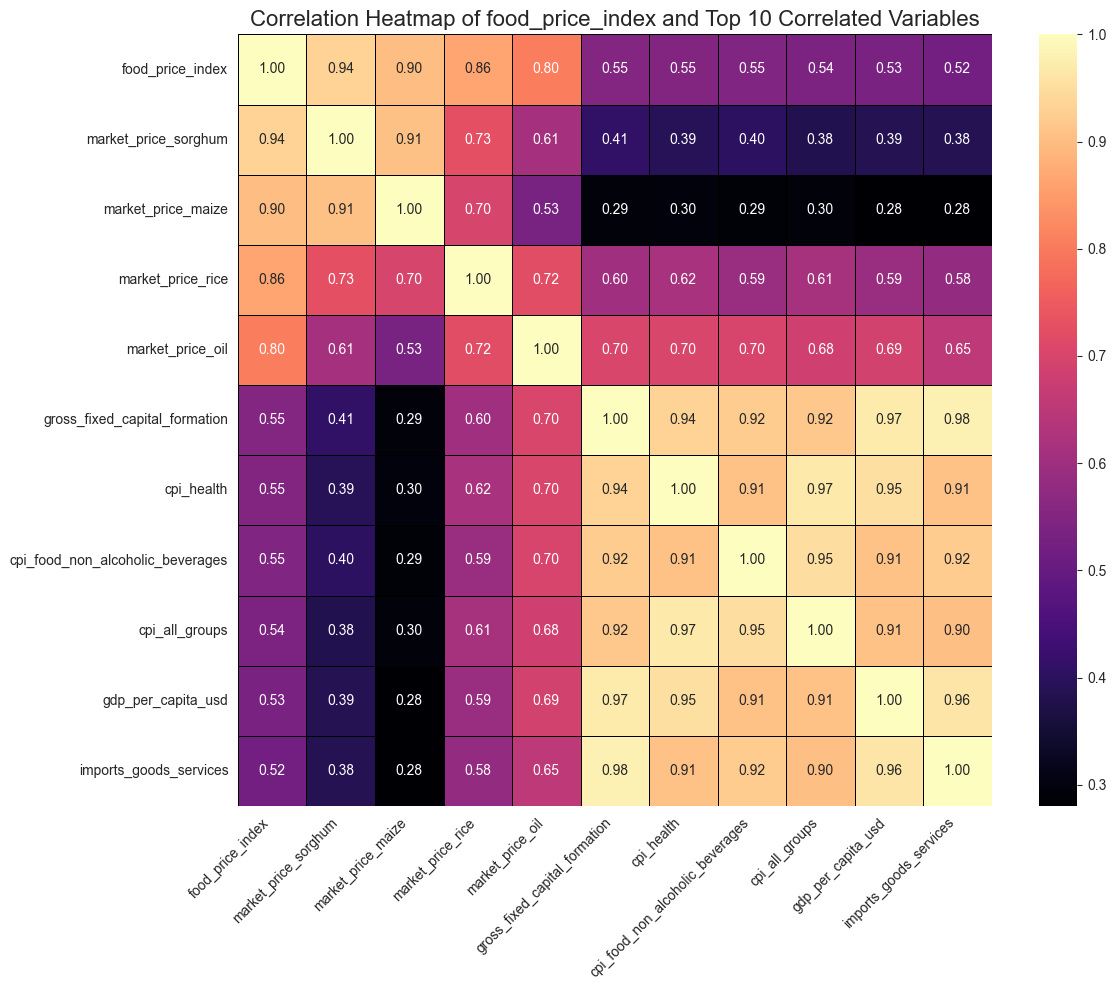

In [58]:
numerical_df_clean = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df_clean.corr(method='pearson')
target_corr = correlation_matrix[TARGET_VARIABLE].sort_values(ascending=False)
top_10_corr = target_corr.head(11).index.tolist()
corr_subset = correlation_matrix.loc[top_10_corr, top_10_corr]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, cmap='magma', fmt=".2f", linewidths=.5, linecolor='black')
plt.title(f'Correlation Heatmap of {TARGET_VARIABLE} and Top 10 Correlated Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Correlation with the Target Variable

The correlation analysis highlights clear linear relationships between several explanatory variables and the Food Price Index. Commodity prices and key macroeconomic indicators emerge as the strongest correlates, while shock-related variables show weaker but still meaningful associations.

**Key Insights:**
- **Commodity Prices:** Individual commodity prices exhibit the strongest positive correlations, confirming their central role in driving movements in the Food Price Index.
- **Macroeconomic Factors:** The exchange rate and GDP per capita show moderate to strong correlations, indicating the influence of broader economic conditions on food price dynamics.
- **Conflict and Drought Shocks:** Conflict and drought indicators display positive but lower linear correlations, suggesting their impacts are significant yet likely non-linear or context-specific.
- **Multicollinearity:** High correlations among commodity prices and related variables point to potential multicollinearity, which should be addressed through dimensionality reduction or feature selection in linear models.


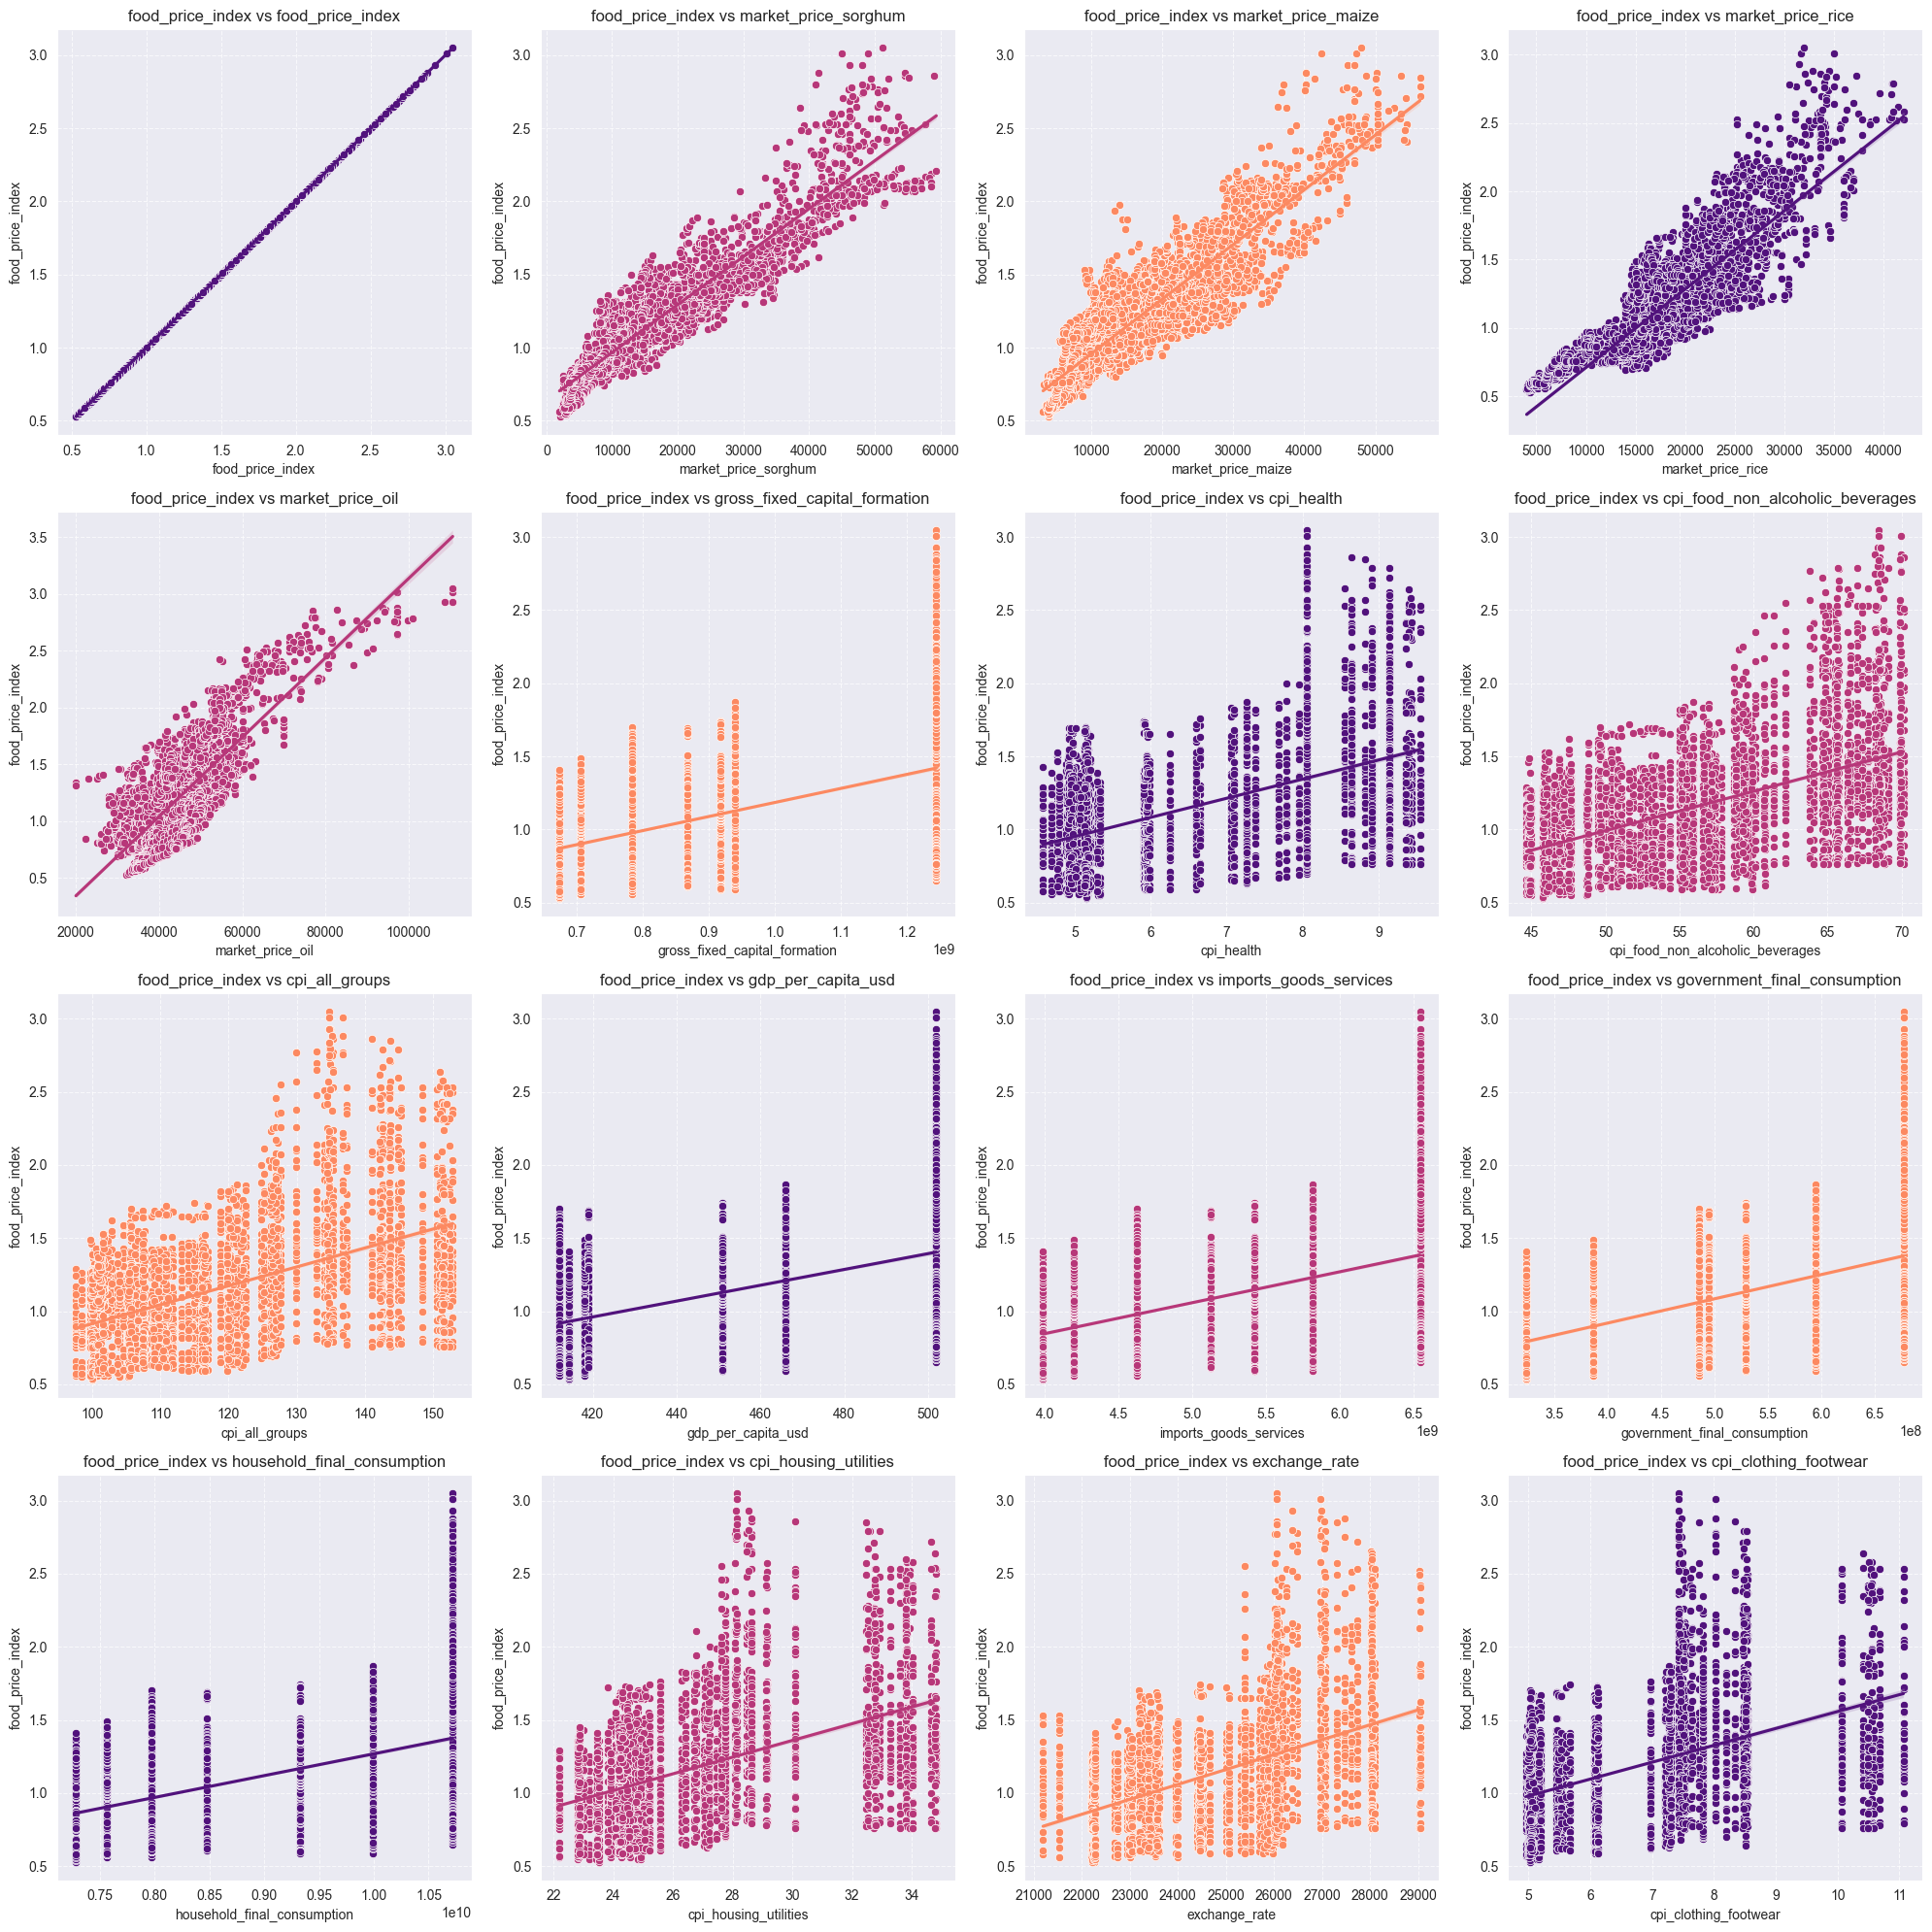

In [59]:
top_corr = target_corr.head(16).index.tolist()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, driver in enumerate(top_corr):
    sns.scatterplot(x=df[driver], y=df[TARGET_VARIABLE], ax=axes[i], color=magma_colors[i % len(magma_colors)])
    sns.regplot(x=df[driver], y=df[TARGET_VARIABLE], ax=axes[i], scatter=False, color=magma_colors[i % len(magma_colors)])
    axes[i].set_title(f'{TARGET_VARIABLE} vs {driver}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

The scatterplots show a consistently positive relationship between the Food Price Index and key market prices, CPI components, and macroeconomic indicators.

- **Strongest associations** appear with staple commodity prices (sorghum, maize, rice) and **fuel/oil prices**, indicating direct cost-push effects on food prices.
- **CPI components** (health, non-alcoholic beverages, housing & utilities, clothing/footwear, education) move upward with food prices, reflecting broad inflation co-movement rather than isolated food shocks.
- **Macroeconomic variables** (GDP per capita, imports of goods & services, household and government consumption, gross fixed capital formation) show moderate positive trends, suggesting food prices rise alongside economic expansion and demand.
- **Exchange rate** depreciation is associated with higher food prices, reflecting the cost of imported goods and the general inflationary pressure
- Vertical banding in several plots suggests **discrete time periods or structural breaks**, while dispersion indicates heterogeneous impacts across observations.

Overall, the visualization highlights that food price dynamics are closely linked to both **commodity markets** and **wider inflationary and macroeconomic conditions**, rather than being driven by a single factor.


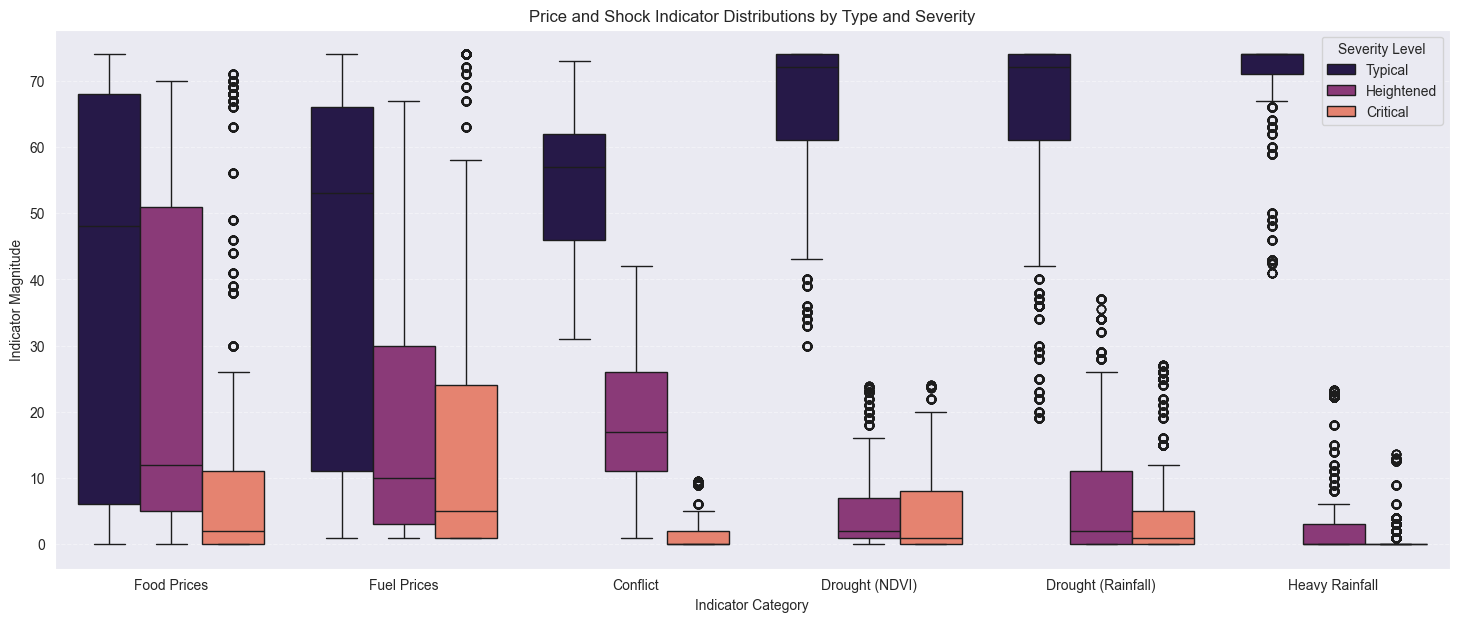

In [63]:
shock_columns = [ 'food_price_critical', 'food_price_heightened', 'food_price_typical', 
                 'fuel_price_critical', 'fuel_price_heightened', 'fuel_price_typical', 
                 'conflict_typical', 'conflict_heightened', 'conflict_critical', 
                 'drought_ndvi_typical', 'drought_ndvi_heightened', 'drought_ndvi_critical', 
                 'drought_rainfall_typical', 'drought_rainfall_heightened', 'drought_rainfall_critical',
                 'heavy_rainfall_critical', 'heavy_rainfall_heightened', 'heavy_rainfall_typical' ]
severity_palette = {
    'Typical': magma_palette[0],
    'Heightened': magma_palette[2],
    'Critical': magma_palette[4]
}
shock_order = [
    'Food Prices',
    'Fuel Prices',
    'Conflict',
    'Drought (NDVI)',
    'Drought (Rainfall)',
    'Heavy Rainfall'
]

severity_order = ['Typical', 'Heightened', 'Critical']

shock_long = (
    df[shock_columns]
    .melt(var_name='variable', value_name='value')
    .dropna()
)

shock_long['shock_type'] = shock_long['variable'].apply(
    lambda x:
        'Food Prices' if 'food_price' in x else
        'Fuel Prices' if 'fuel_price' in x else
        'Conflict' if 'conflict' in x else
        'Drought (NDVI)' if 'ndvi' in x else
        'Drought (Rainfall)' if 'drought_rainfall' in x else
        'Heavy Rainfall' if 'heavy_rainfall' in x else
        'Unknown'
)

shock_long['severity'] = shock_long['variable'].apply(
    lambda x: x.split('_')[-1].capitalize()
)

plt.figure(figsize=(18, 7))

sns.boxplot(
    data=shock_long,
    x='shock_type',
    y='value',
    hue='severity',
    order=shock_order,
    hue_order=severity_order,
    palette=severity_palette
)

plt.title("Price and Shock Indicator Distributions by Type and Severity")
plt.xlabel("Indicator Category")
plt.ylabel("Indicator Magnitude")
plt.legend(title="Severity Level")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


### Price and Shock Indicator Distributions

- **Prices vs Shocks:** Food and fuel prices show higher magnitudes and wider variability compared to conflict and drought indicators, which are more episodic and threshold-based.  
- **Severity Patterns:** Across all categories, severity levels generally follow the expected gradient—*Typical* values dominate in frequency, while *Critical* values are fewer but more extreme.  
- **Drought Indicators:** NDVI- and rainfall-based drought measures exhibit heavy tails and outliers, highlighting spatially and temporally localized extreme events.  
- **Modeling Implications:** Differences in scale and distribution suggest standardization is necessary, and non-linear or interaction-aware models are better suited to capture how shocks affect food prices.


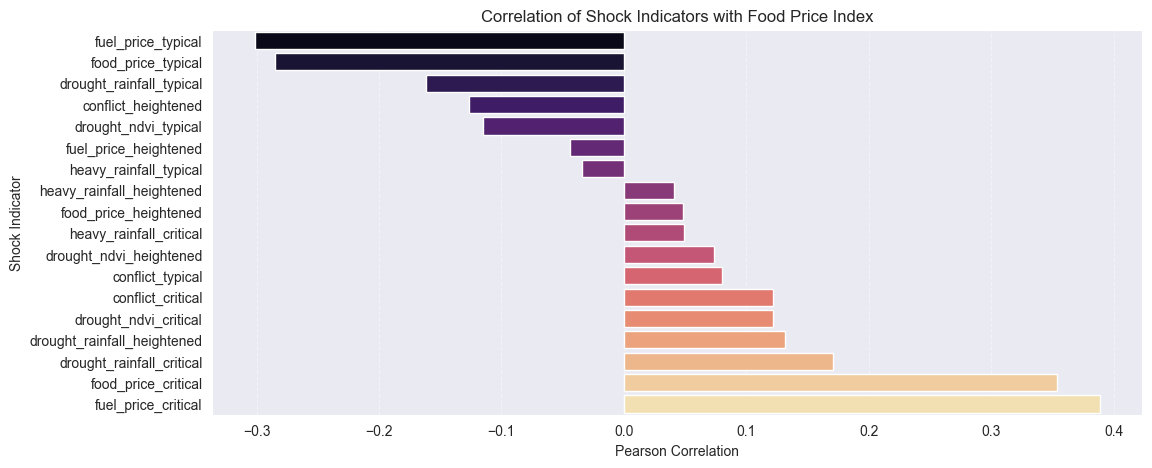

In [66]:
corr_df = df[shock_columns + [TARGET_VARIABLE]].corr()[TARGET_VARIABLE].drop(TARGET_VARIABLE)

corr_df = corr_df.sort_values()
plt.figure(figsize=(12, 5))

sns.barplot(
    x=corr_df.values,
    y=corr_df.index,
    palette='magma'
)

plt.title("Correlation of Shock Indicators with Food Price Index")
plt.xlabel("Pearson Correlation")
plt.ylabel("Shock Indicator")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()



The correlation analysis highlights **clear severity-dependent relationships** between shock indicators and the Food Price Index.

- **Critical-level shocks** exhibit the strongest positive associations with food prices, particularly:
  **Fuel Price (Critical)** and **Food Price (Critical)**, indicating strong cost pass-through and market pressure effects.
  **Drought (Rainfall – Critical)**, emphasizing the role of rainfall failure in driving supply-side price increases.

- **Moderate (Heightened) shocks** show weak or near-zero correlations, suggesting that intermediate stress levels may not immediately translate into higher food prices or may operate with time lags.

- **Typical (normal) conditions** are generally **negatively correlated** with food prices, reflecting baseline stability and lower inflationary pressure during non-crisis periods.

- **Conflict and drought (NDVI)** shocks become relevant mainly at **critical severity**, reinforcing the presence of **nonlinear and threshold effects** in food price dynamics.

### Key Implications
- Food price inflation is primarily driven by acute, severe shocks rather than average conditions.
- Modeling approaches should prioritize:
  - Critical severity indicators
  - Lagged heightened indicators for early warning
  - Severity-weighted or aggregated shock indices to capture nonlinear effects.


## Trend analysis of FPI and Major Factors



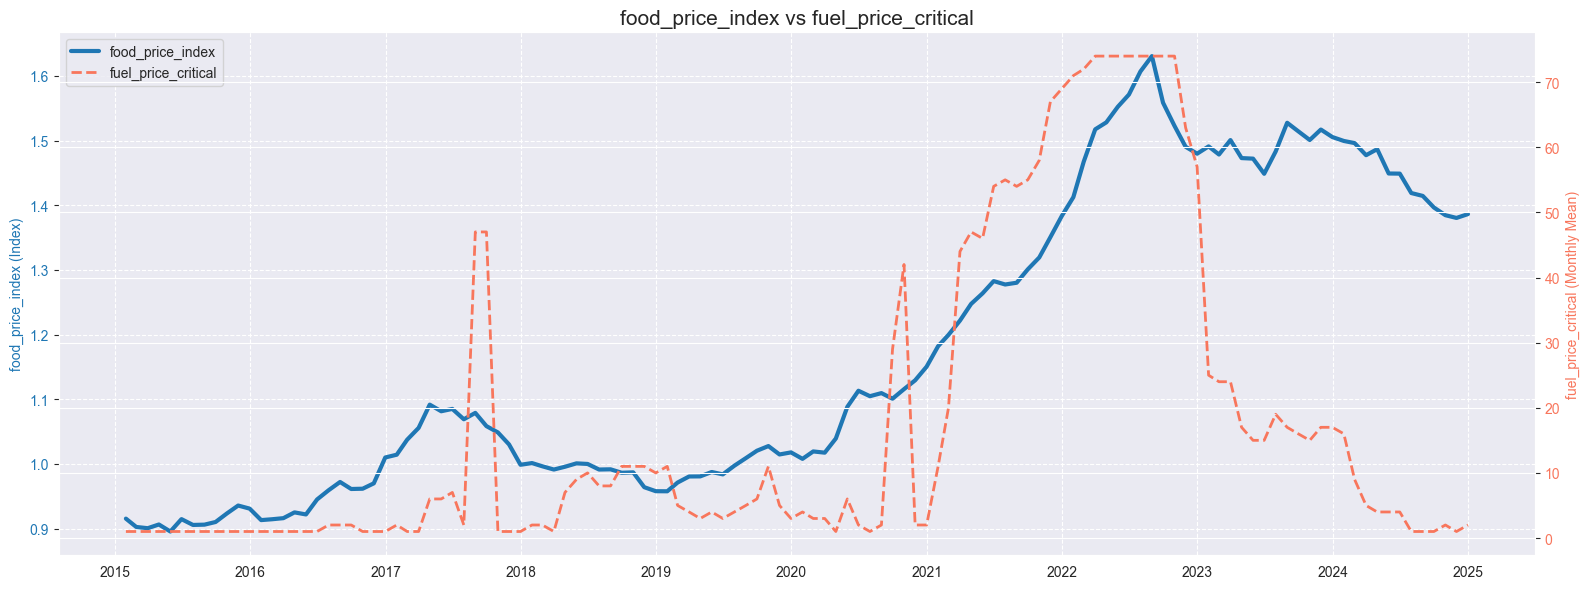

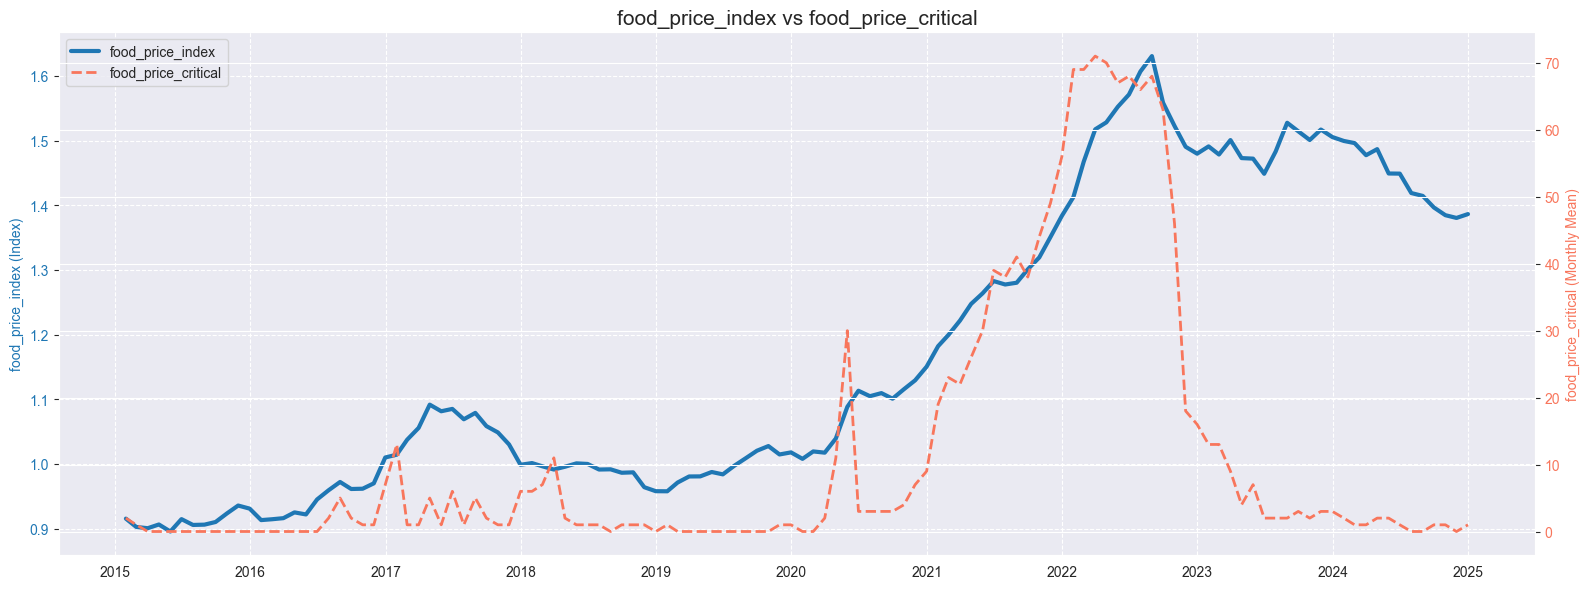

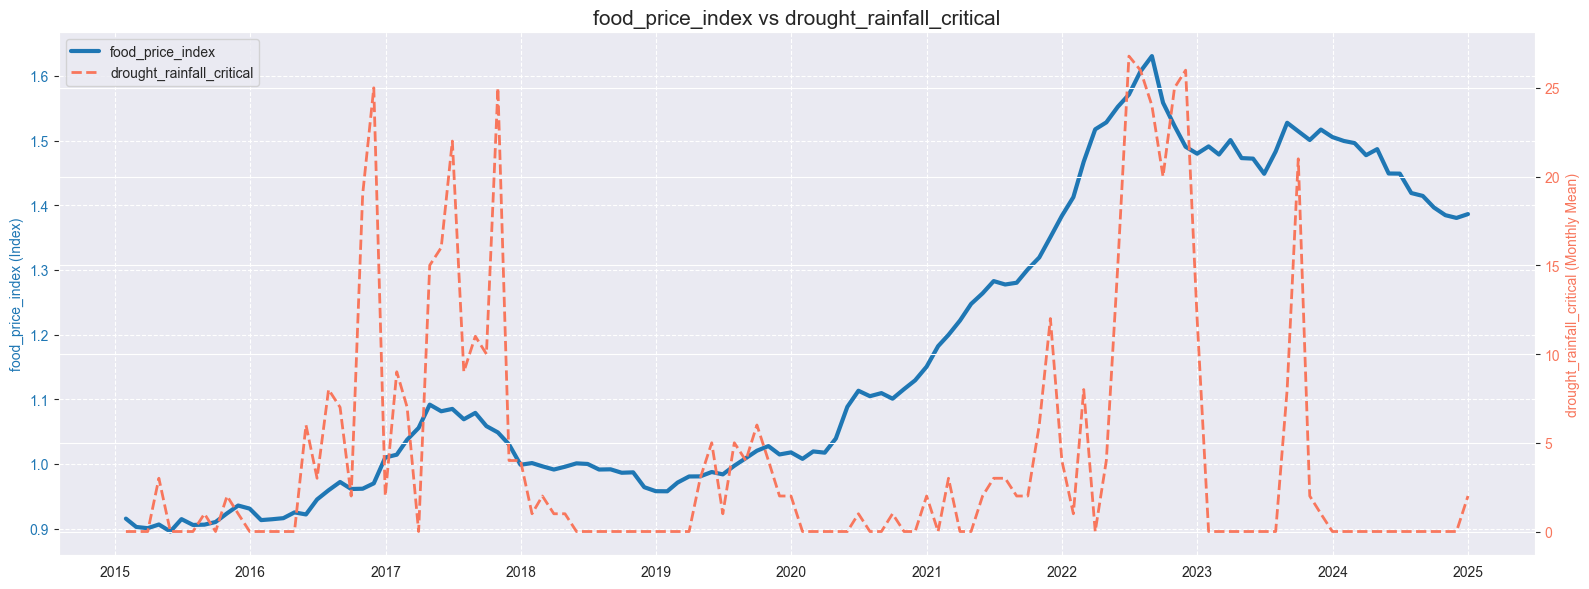

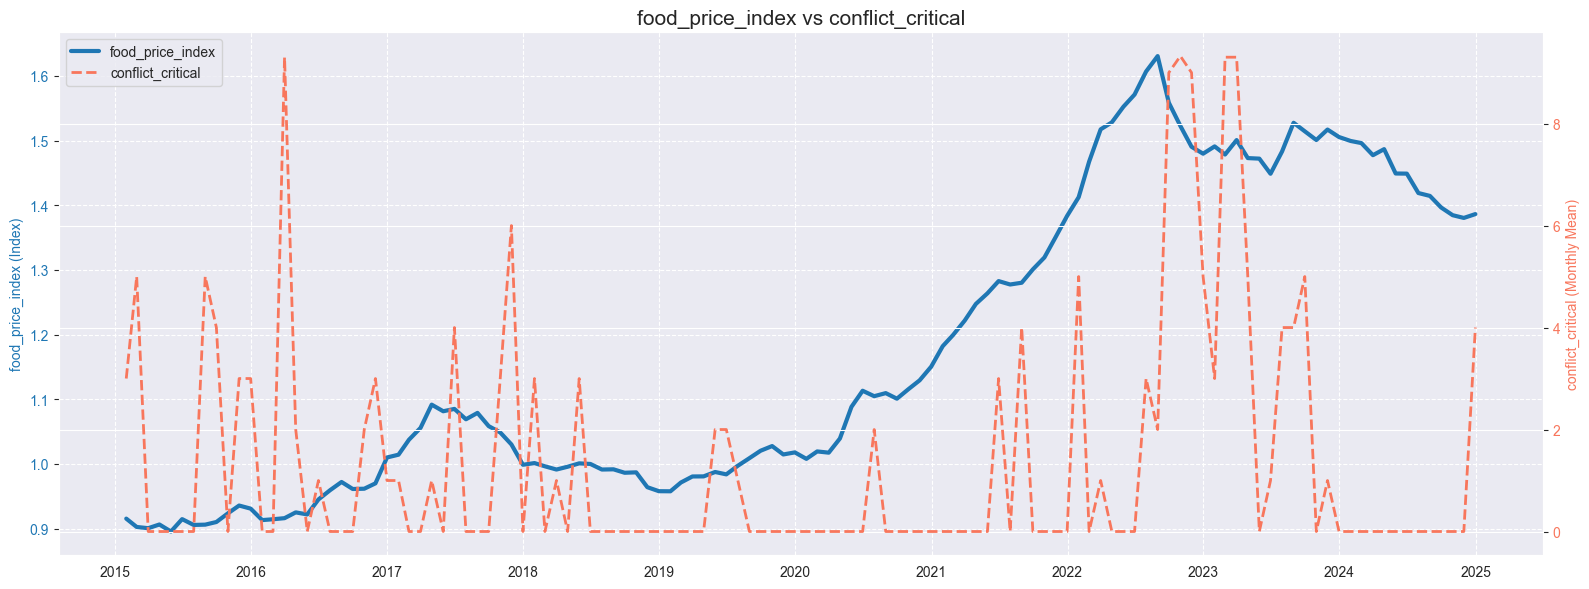

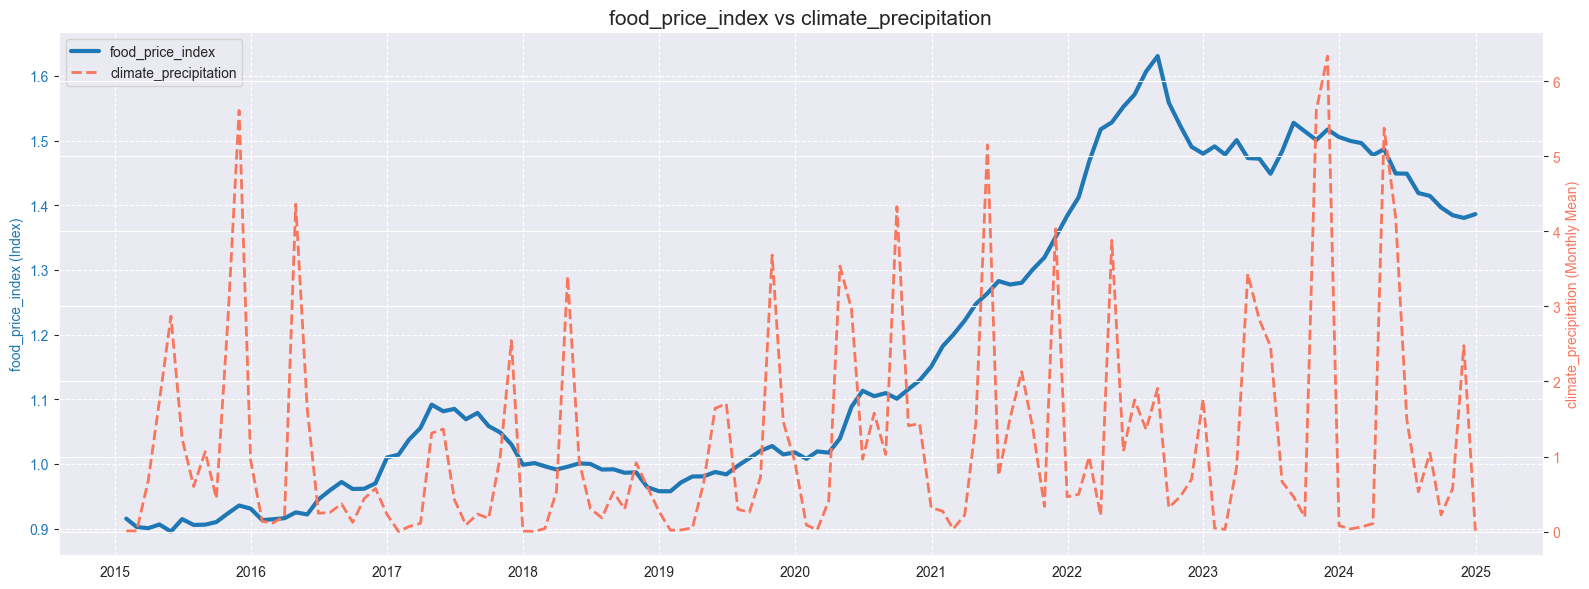

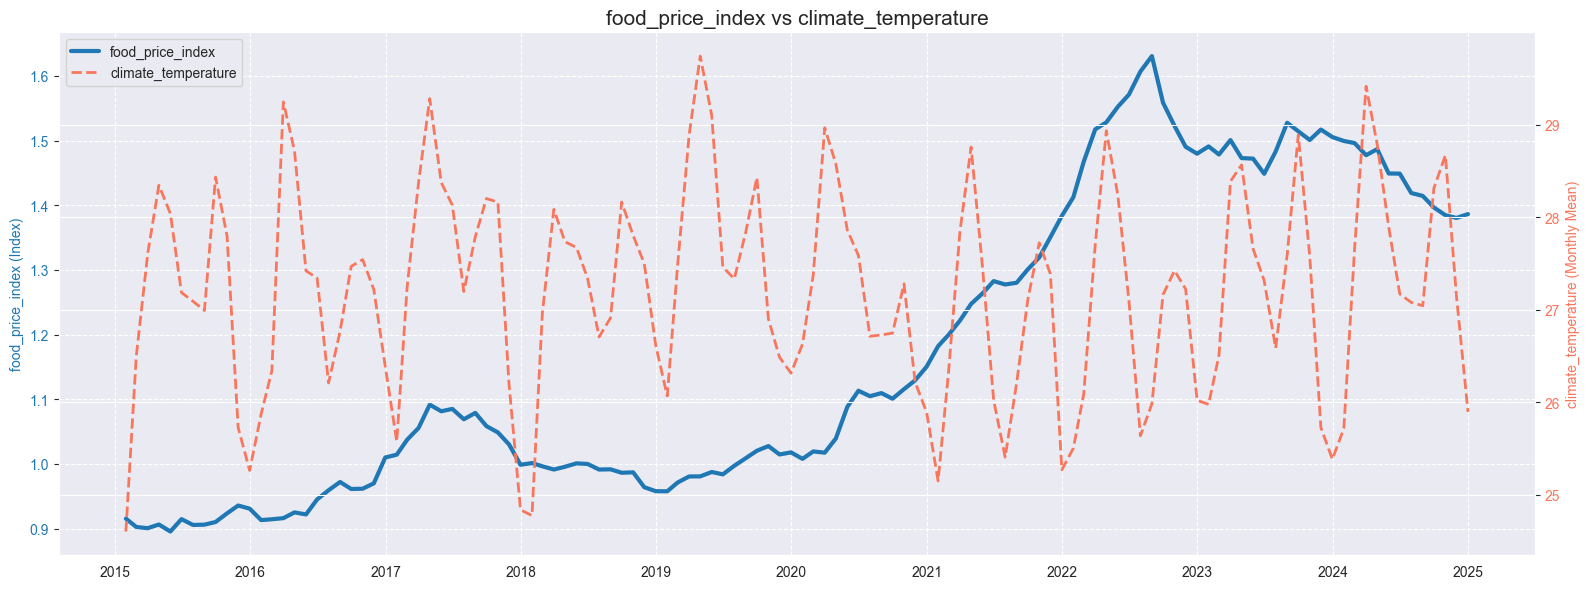

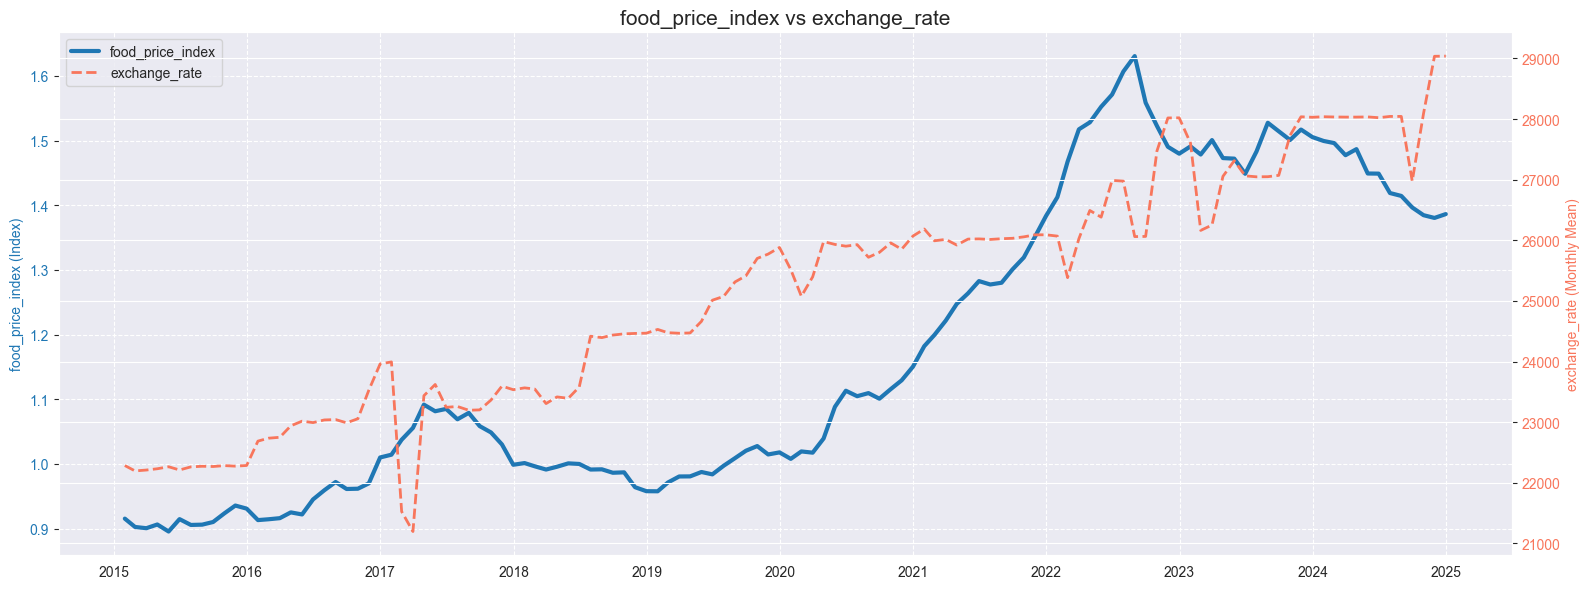

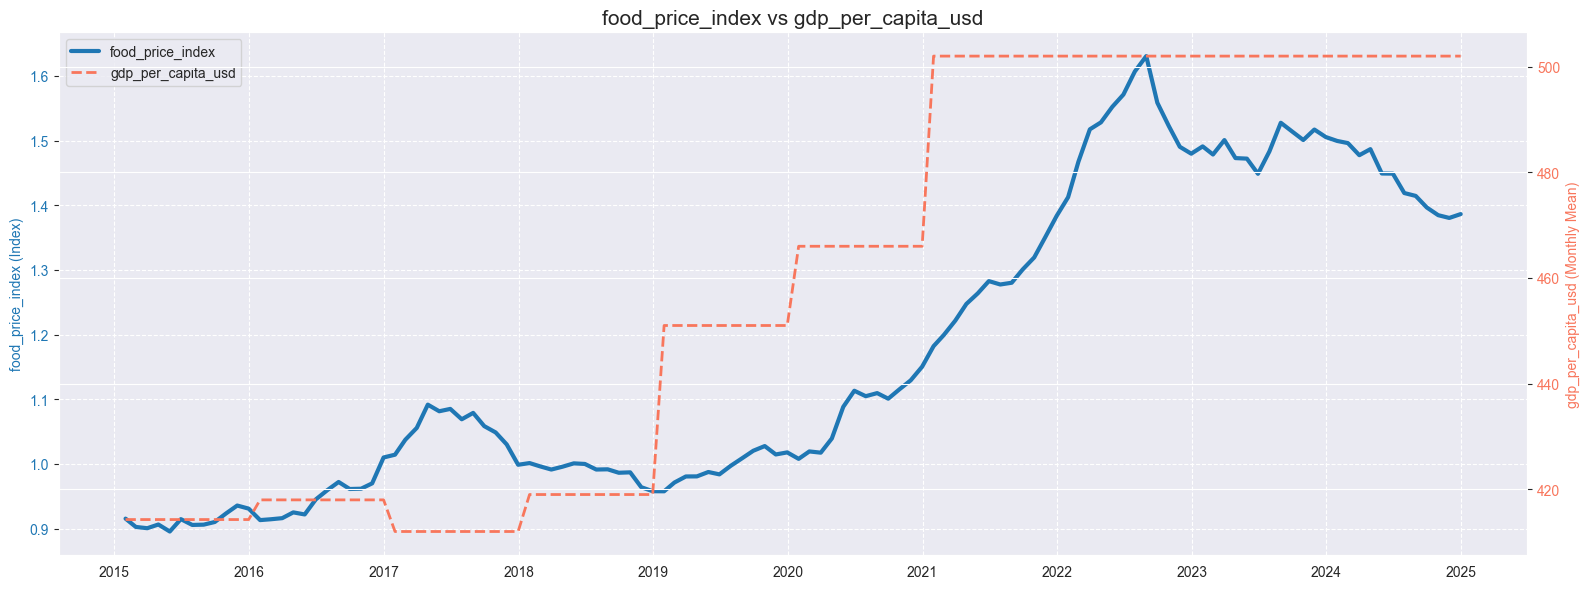

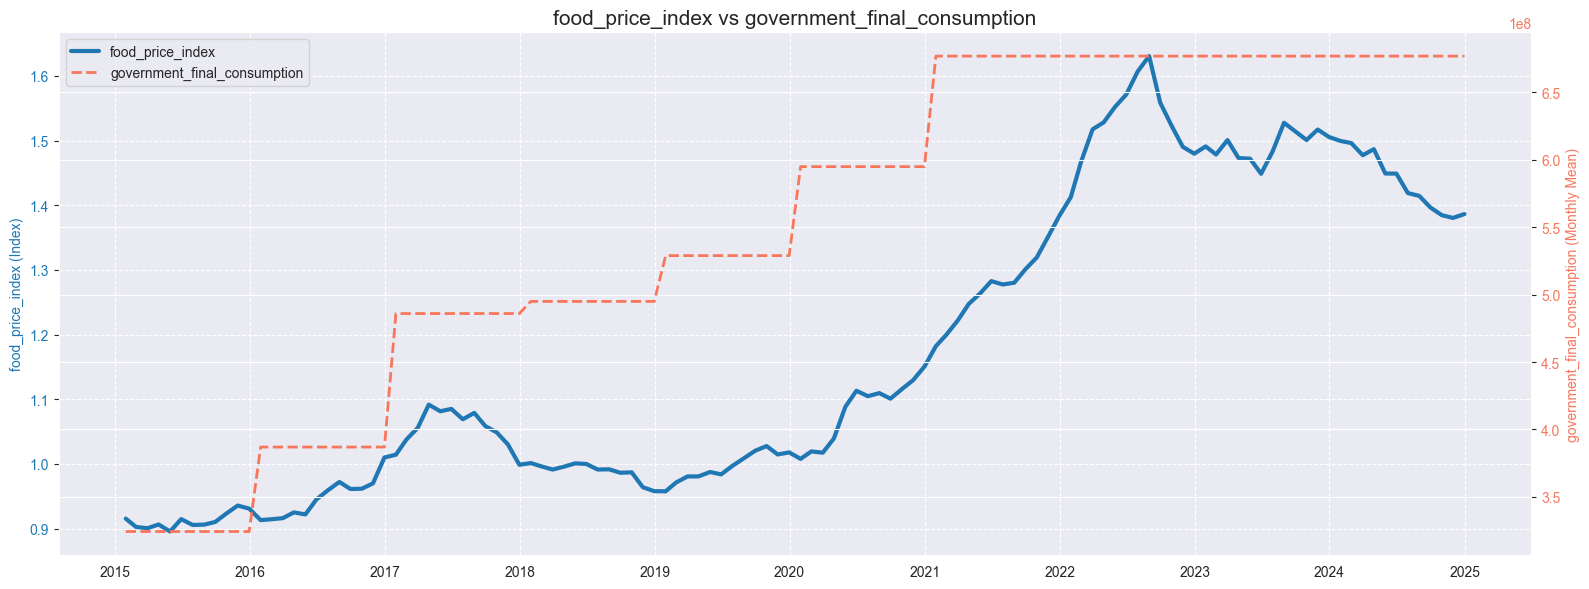

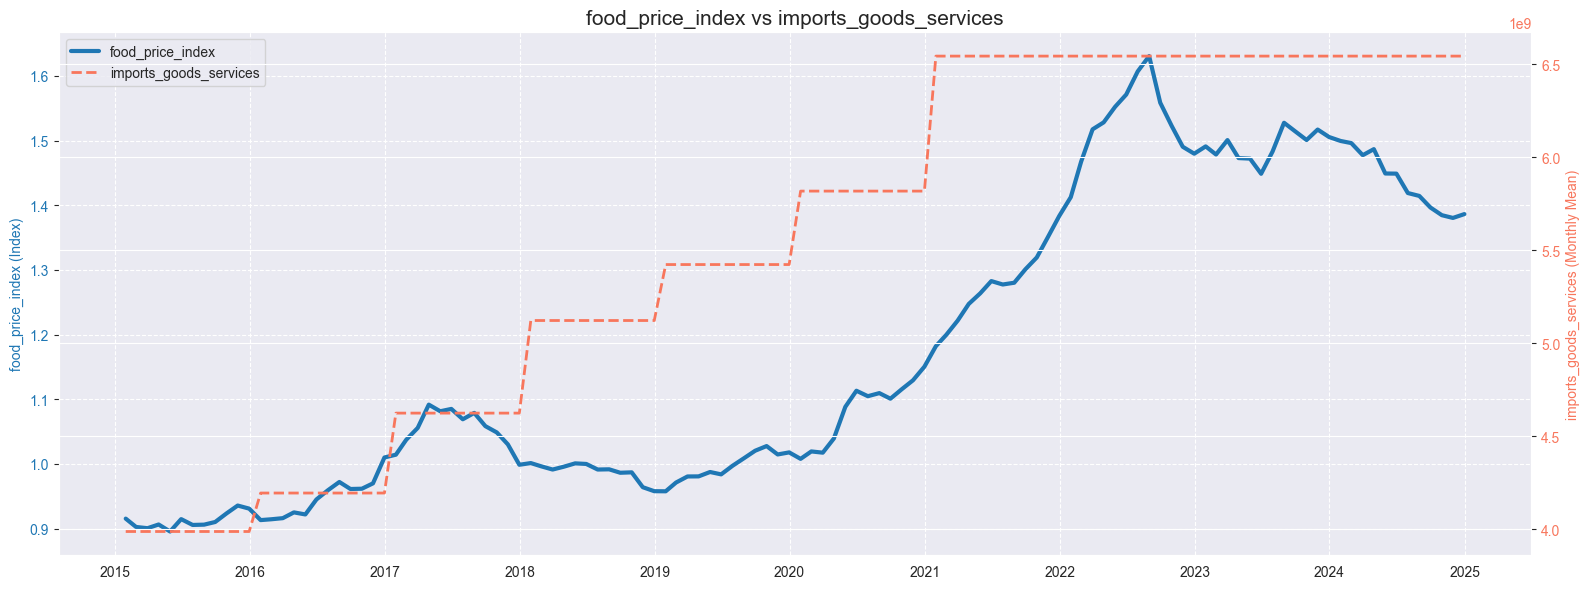

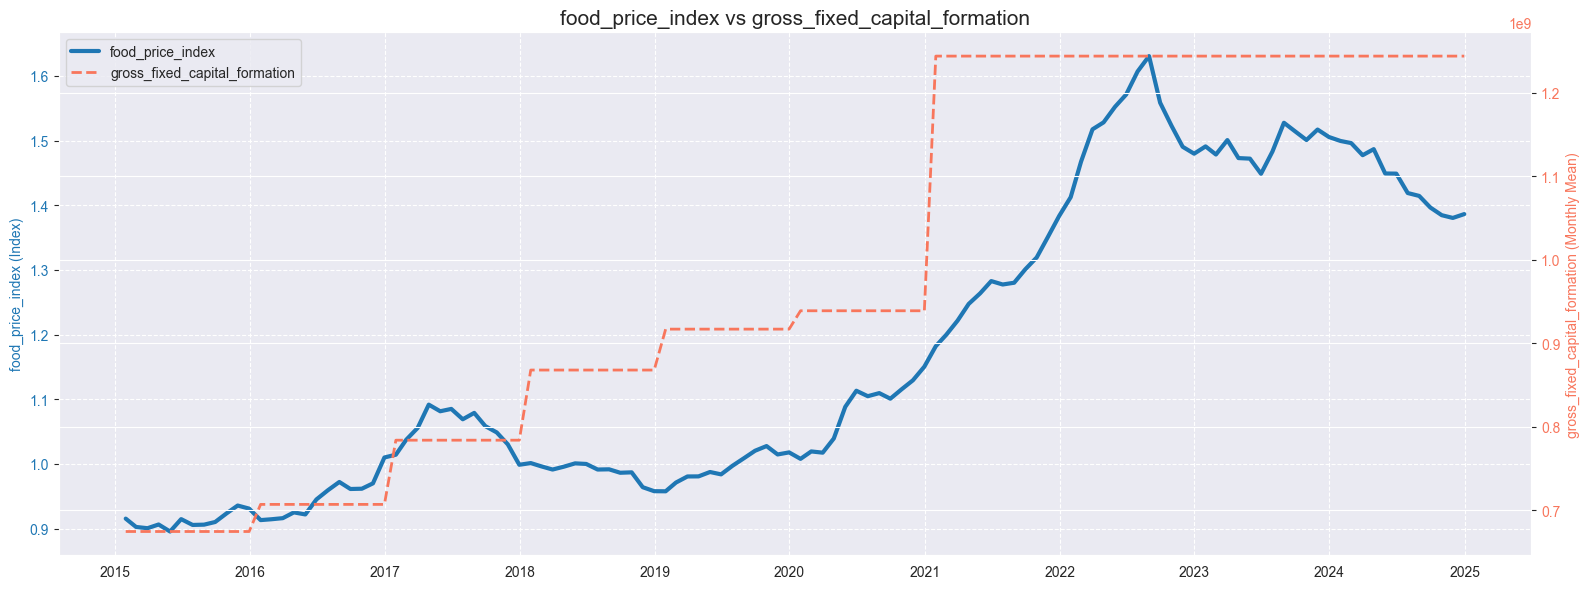

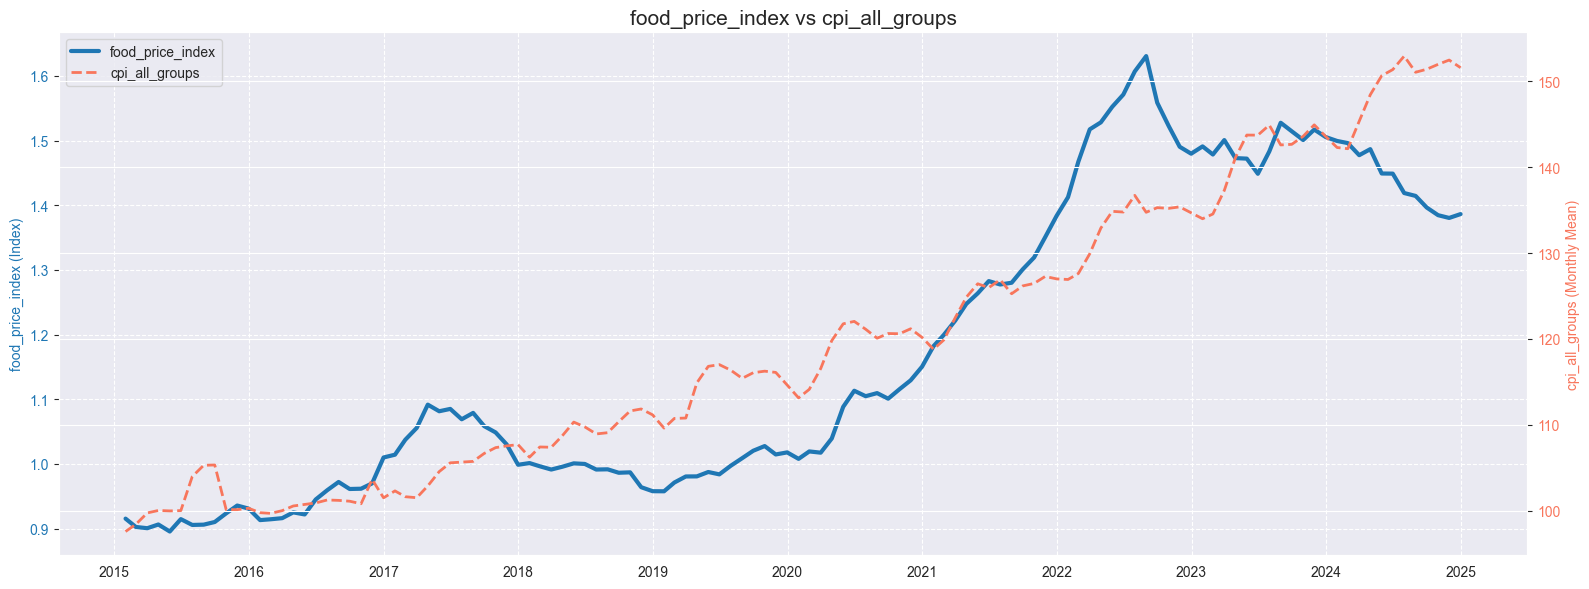

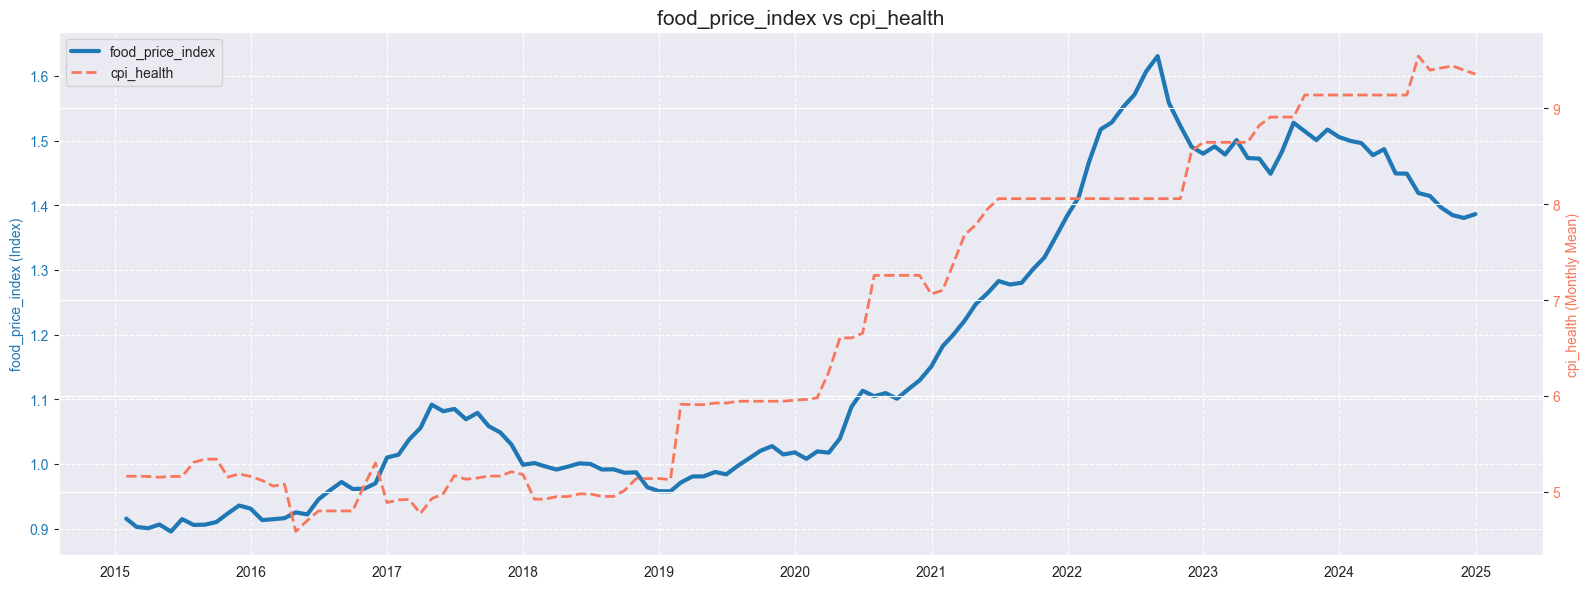

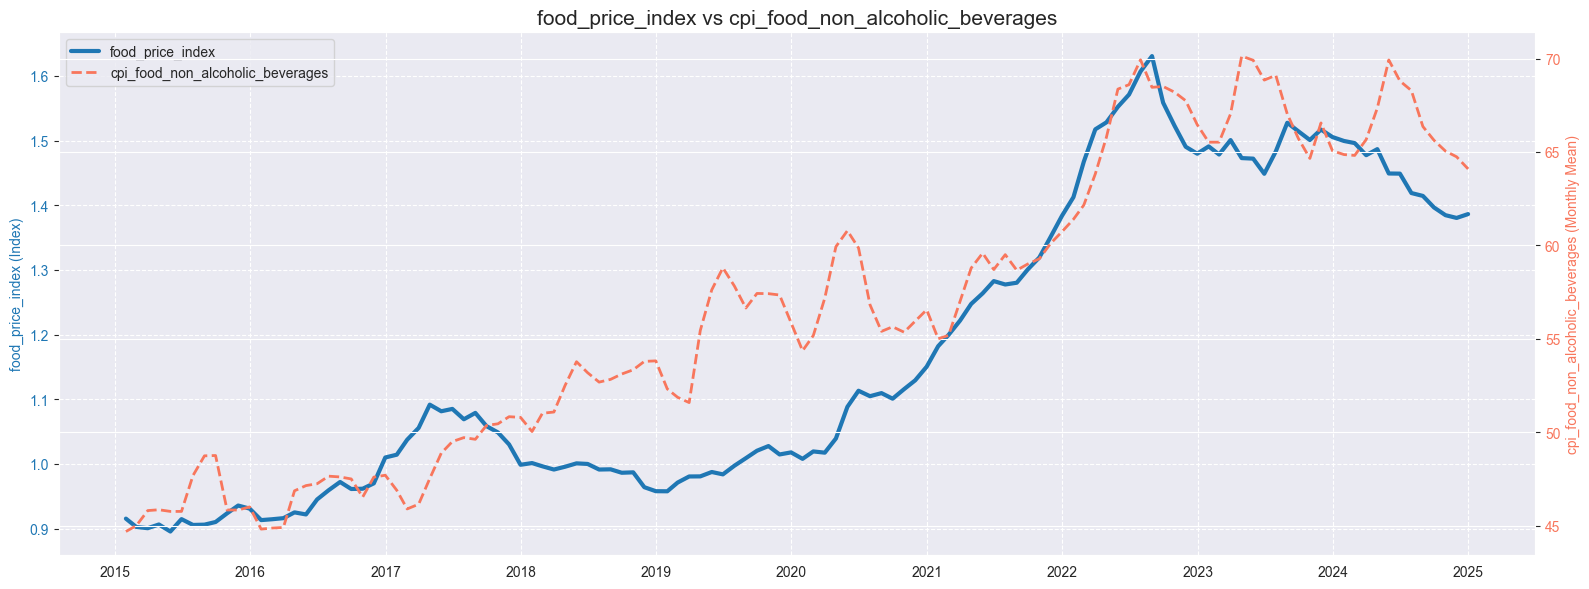

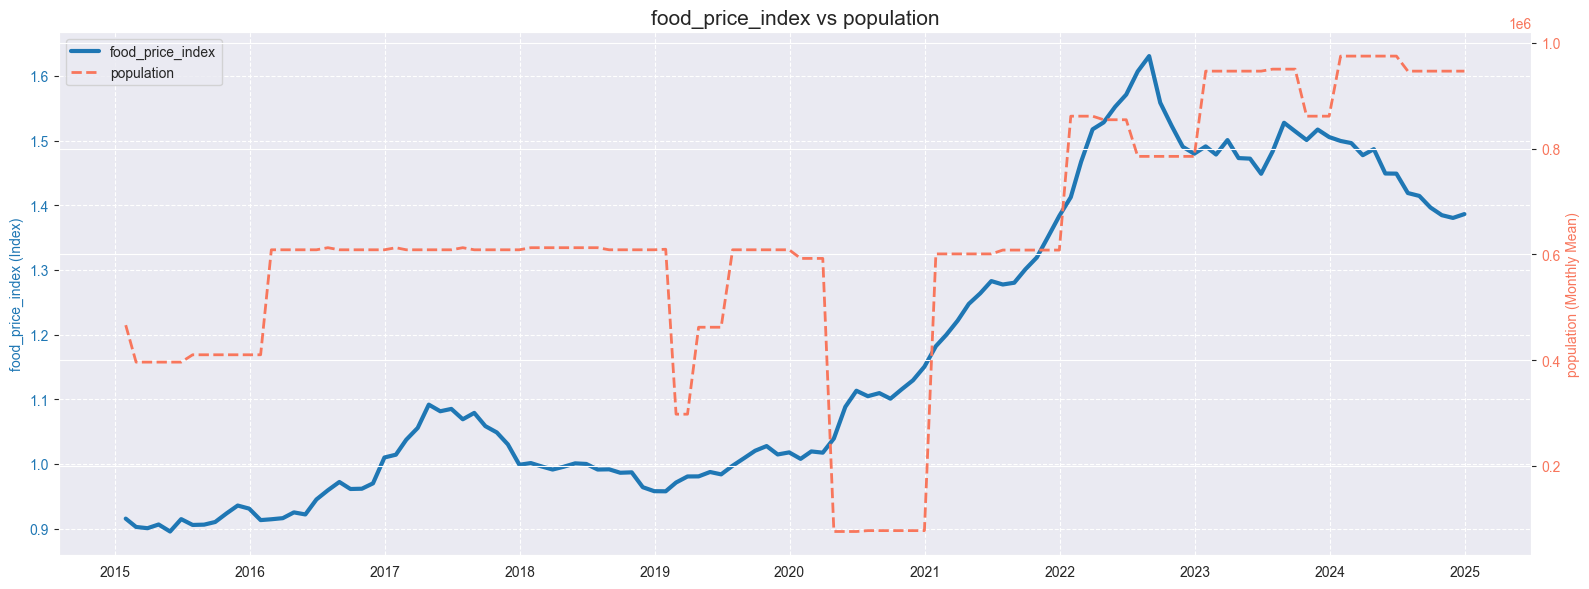

In [67]:
df_national = (
    df
    .select_dtypes(include=np.number)
    .resample('M')
    .mean()
)

vars = [
    'fuel_price_critical',
    'food_price_critical',
    'drought_rainfall_critical',
    'conflict_critical',
    'climate_precipitation',
    'climate_temperature',
    'exchange_rate',
    'gdp_per_capita_usd',
    'government_final_consumption',
    'imports_goods_services',
    'gross_fixed_capital_formation',
    'cpi_all_groups',
    'cpi_health',
    'cpi_food_non_alcoholic_beverages',
    'population'

]

for var in vars:

    if var not in df_national.columns:
        continue

    fig, ax1 = plt.subplots(figsize=(16, 6))

    line_fpi, = ax1.plot(
        df_national.index,
        df_national[TARGET_VARIABLE],
        linewidth=3,
        label=TARGET_VARIABLE
    )

    ax1.set_ylabel(f'{TARGET_VARIABLE} (Index)', color='#1f77b4')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.grid(True, linestyle='--')

    ax2 = ax1.twinx()

    line_var, = ax2.plot(
        df_national.index,
        df_national[var],
        color=magma_palette[4],
        linestyle='--',
        linewidth=2,
        label=var
    )

    ax2.set_ylabel(f'{var} (Monthly Mean)', color=magma_palette[4])
    ax2.tick_params(axis='y', labelcolor=magma_palette[4])

    ax1.legend(
        handles=[line_fpi, line_var],
        loc='upper left',
        frameon=True
    )

    plt.title(f'{TARGET_VARIABLE} vs {var}', fontsize=15)
    plt.tight_layout()
    plt.show()



**Short-Term, Episodic Shocks**  
Critical-level shock indicators—specifically food price, drought, and conflict—exhibit sharp, short-lived spikes that tend to precede or coincide with pronounced peaks in the Food Price Index (FPI). This pattern indicates that sudden inflationary surges are primarily triggered by **acute, severe events**, rather than by moderate or typical shock conditions. These shocks act as catalysts for short-term volatility rather than shaping the long-run trajectory of food prices.

**Long-Term, Systemic Macroeconomic Drivers**  
- **Exchange Rate:** The exchange rate shows a strong and synchronous positive co-movement with the FPI. Its persistent upward trend closely mirrors the non-stationary behavior of the FPI, identifying it as a key continuous driver of food price inflation over time.  
- **Structural Economic Indicators:** GDP per capita, government final consumption, imports of goods and services, and gross fixed capital formation all demonstrate sustained positive relationships with the FPI. The alignment of their long-term trends with rising food prices suggests that inflation is deeply embedded within broader economic growth dynamics and structural transformation, rather than being driven solely by temporary shocks.  
- **CPI Food and Non-Alcoholic Beverages:** Exhibits strong, persistent co-movement with the FPI across the full period, indicating that food price inflation is embedded within the broader consumer inflation system and driven by shared macroeconomic and cost-push forces rather than isolated shocks.
- **CPI Health:** The close co-movement between CPI Health and the FPI reinforces the interpretation that food price inflation is part of a wider, economy-wide inflationary environment.

**Climate Variables**  
Precipitation and temperature exhibit strong seasonality and high short-term volatility, while the FPI follows a much smoother, non-stationary trend. This mismatch in temporal structure implies that **seasonal climate fluctuations do not directly translate into immediate or large-scale movements in food prices**, although they may still exert indirect or lagged effects.


**Population**
Evolves slowly and in stepwise jumps that do not align with FPI fluctuations, implying no direct role in short- or medium-term food price inflation and highlighting its relevance only for very long-run demand pressure, not inflation dynamics.



## Regional Analysis: Understanding Granularity

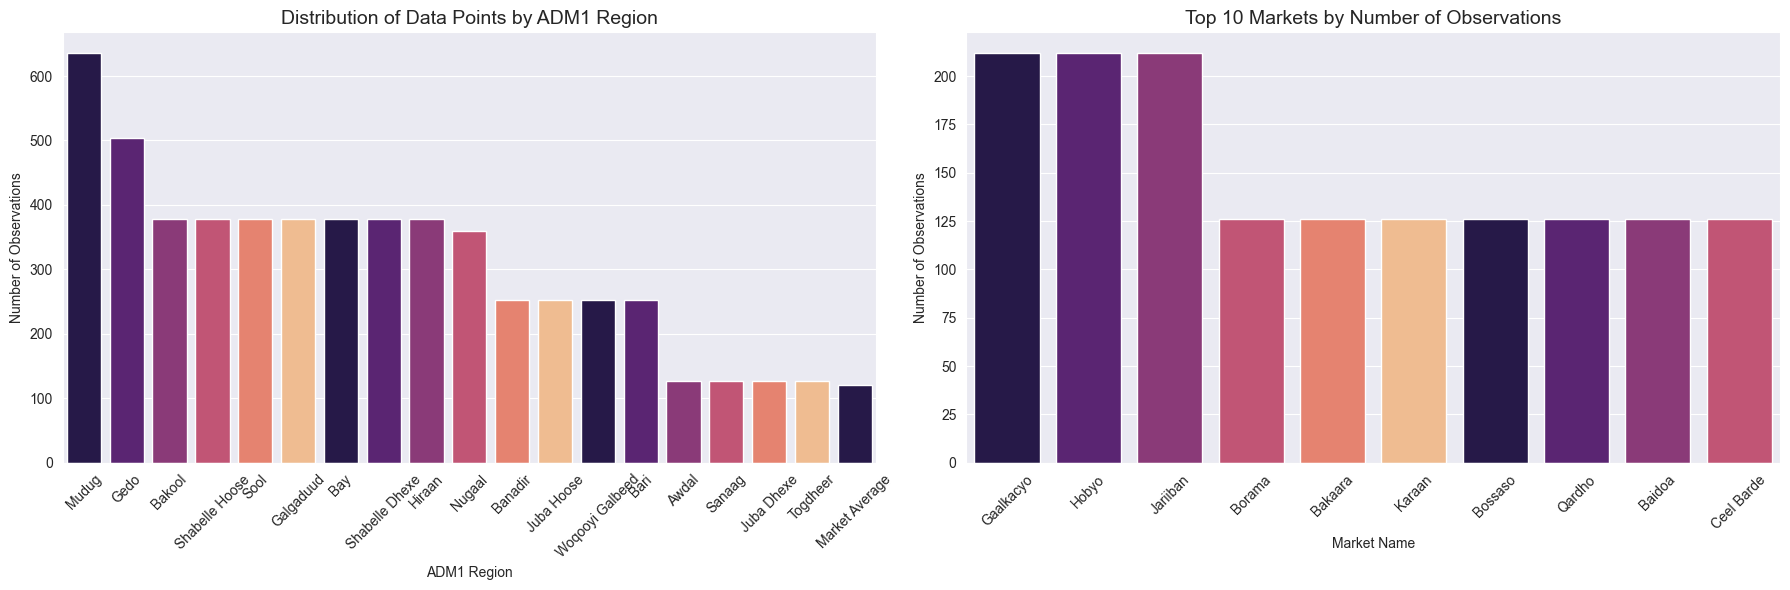

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

adm1_counts = df['adm1_name'].value_counts().sort_values(ascending=False)
sns.barplot(x=adm1_counts.index, y=adm1_counts.values, palette=magma_palette, ax=axes[0])
axes[0].set_title('Distribution of Data Points by ADM1 Region', fontsize=14)
axes[0].set_ylabel('Number of Observations')
axes[0].set_xlabel('ADM1 Region')
axes[0].tick_params(axis='x', rotation=45)

mkt_counts = df['mkt_name'].value_counts().head(10)
sns.barplot(x=mkt_counts.index, y=mkt_counts.values, palette=magma_palette, ax=axes[1])
axes[1].set_title('Top 10 Markets by Number of Observations', fontsize=14)
axes[1].set_ylabel('Number of Observations')
axes[1].set_xlabel('Market Name')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Data Concentration
The distribution plots reveal a significant concentration of data in certain regions and markets. This is crucial: regions with more data points will have more reliable time series and correlation estimates. Conversely, regions with sparse data may require caution in interpretation. This heterogeneity in data availability is a key finding for any subsequent modeling.


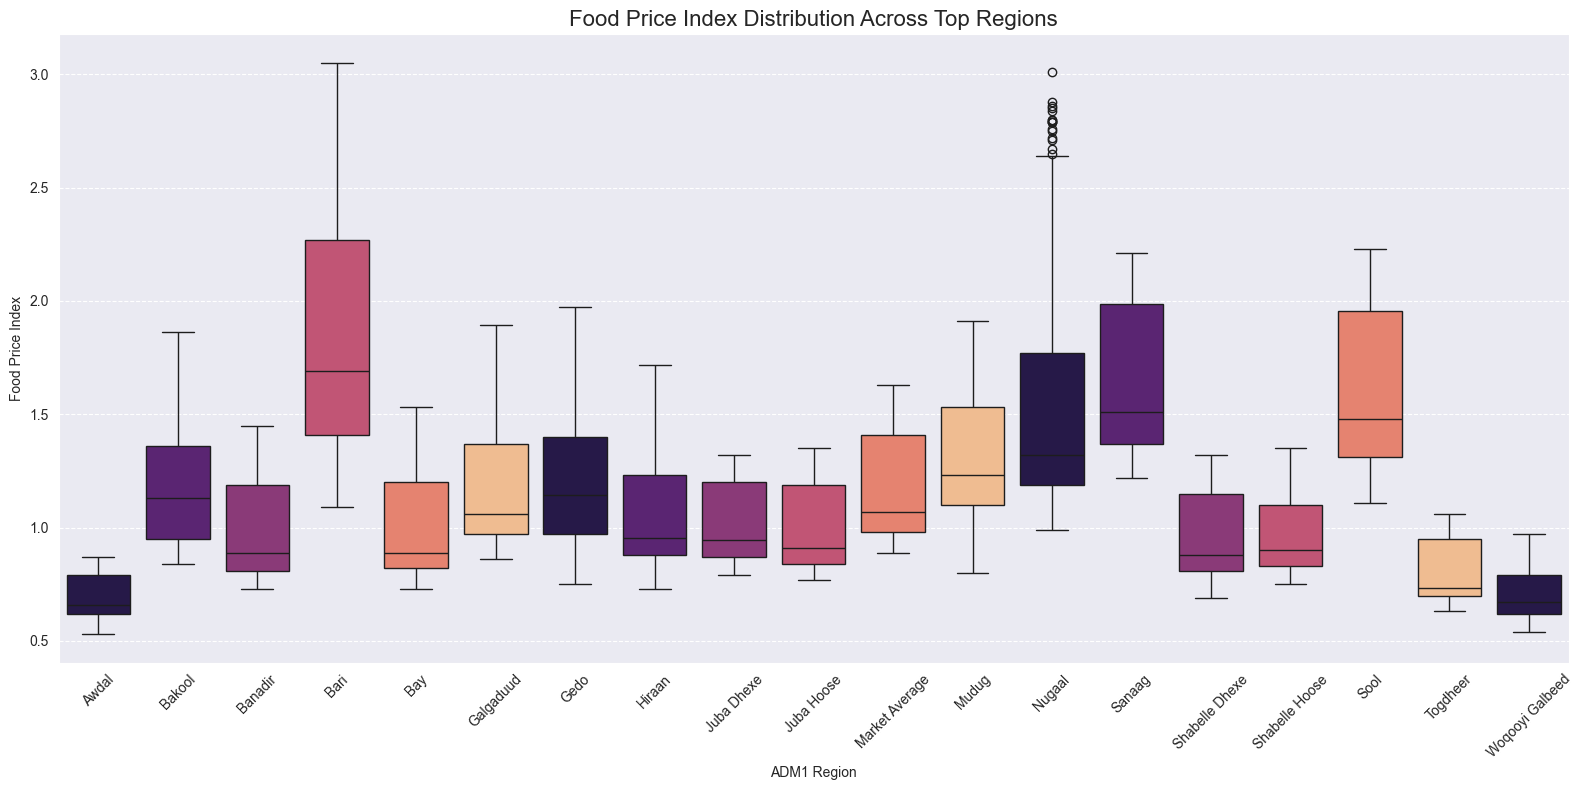

In [69]:
top_adm1 = df['adm1_name'].value_counts().index.tolist()
df_top_adm1 = df[df['adm1_name'].isin(top_adm1)]

plt.figure(figsize=(16, 8))
sns.boxplot(x='adm1_name', y=TARGET_VARIABLE, data=df_top_adm1, palette=magma_palette)
plt.title('Food Price Index Distribution Across Top Regions', fontsize=16)
plt.xlabel('ADM1 Region')
plt.ylabel('Food Price Index')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()


*   **Regional Disparity:** The **absolute level** of the index varies significantly between regions, indicating persistent regional differences in market structure, supply chain efficiency, or local cost of living.



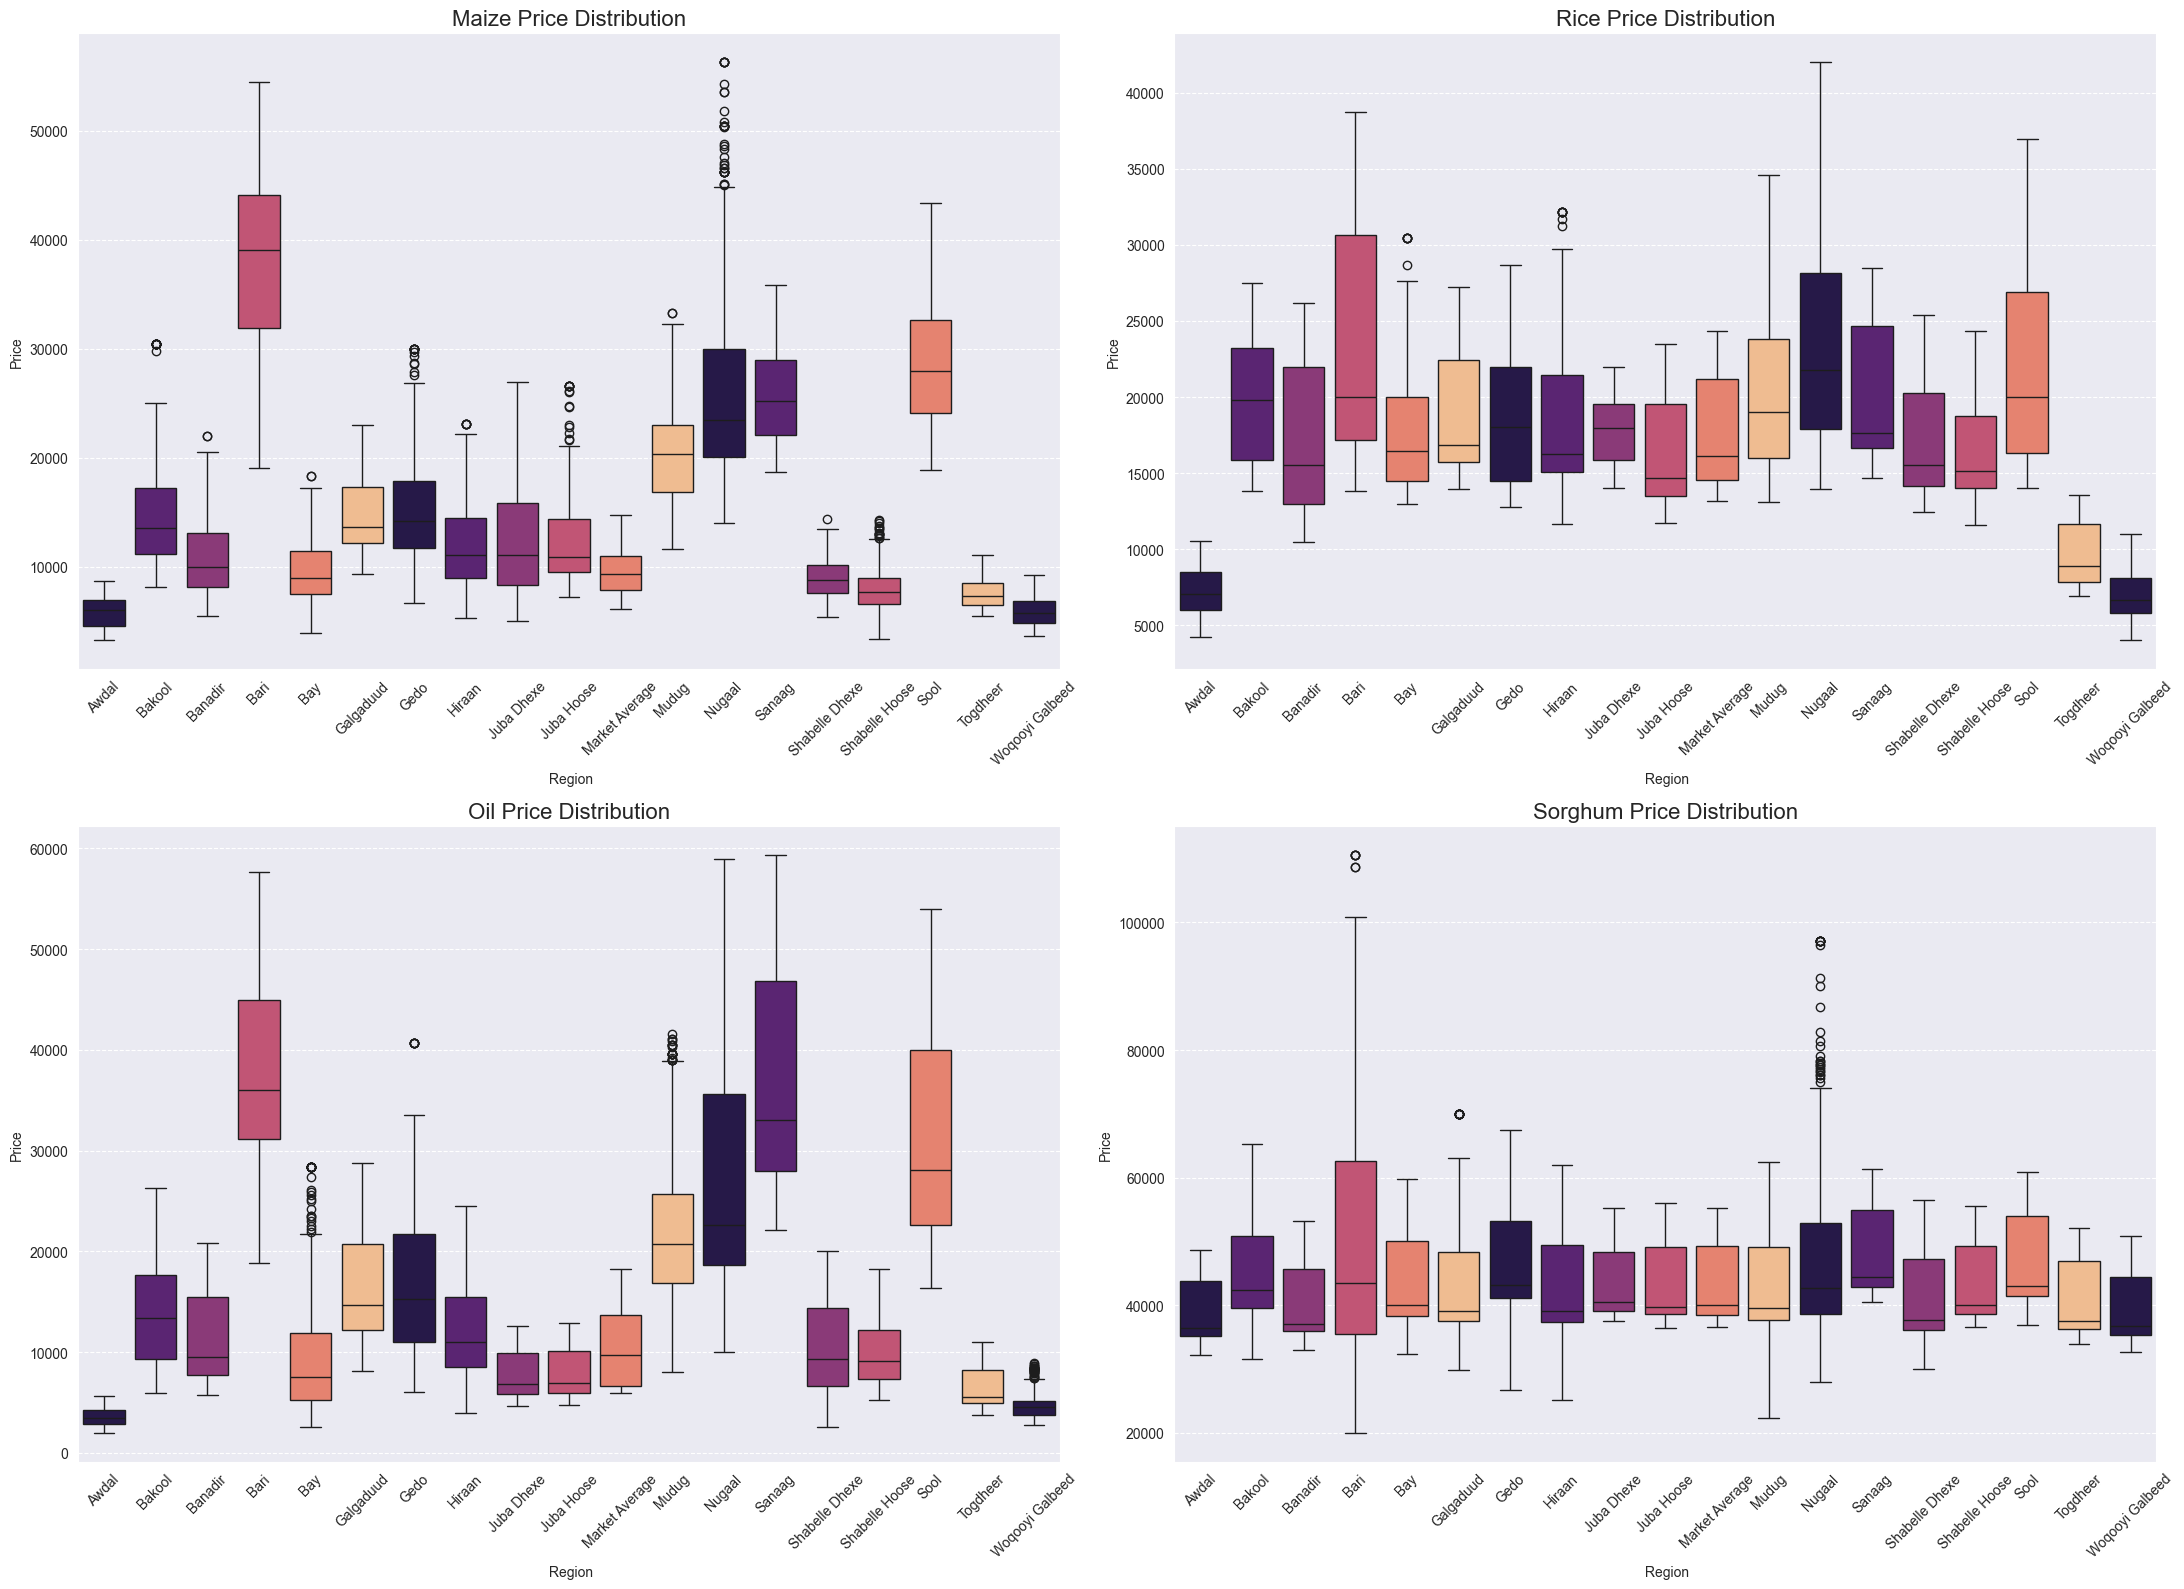

In [70]:
commodities = {
    'Maize': 'market_price_maize',
    'Rice': 'market_price_rice',
    'Oil': 'market_price_sorghum',
    'Sorghum': 'market_price_oil'
}

top_adm1 = df['adm1_name'].value_counts().index.tolist()
df_top_adm1 = df[df['adm1_name'].isin(top_adm1)]

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

axes = axes.flatten()

for ax, (commodity_name, column) in zip(axes, commodities.items()):
    sns.boxplot(
        x='adm1_name',
        y=column,
        data=df_top_adm1,
        palette=magma_palette,
        ax=ax
    )
    
    ax.set_title(f'{commodity_name} Price Distribution', fontsize=16)
    ax.set_xlabel(' Region')
    ax.set_ylabel('Price')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--')

plt.tight_layout()

plt.show()

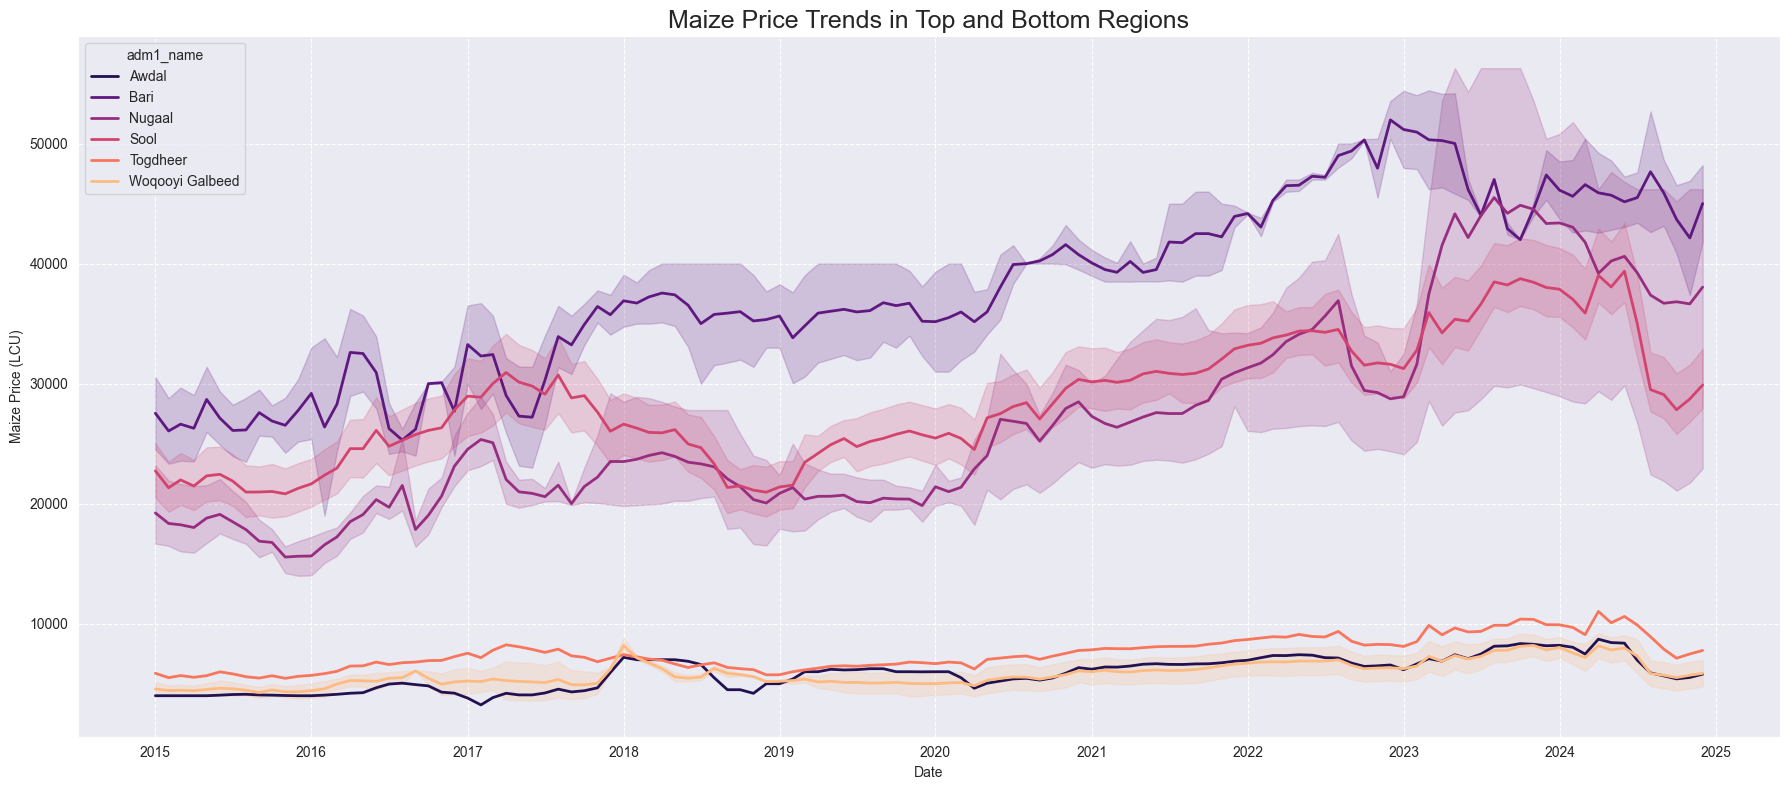

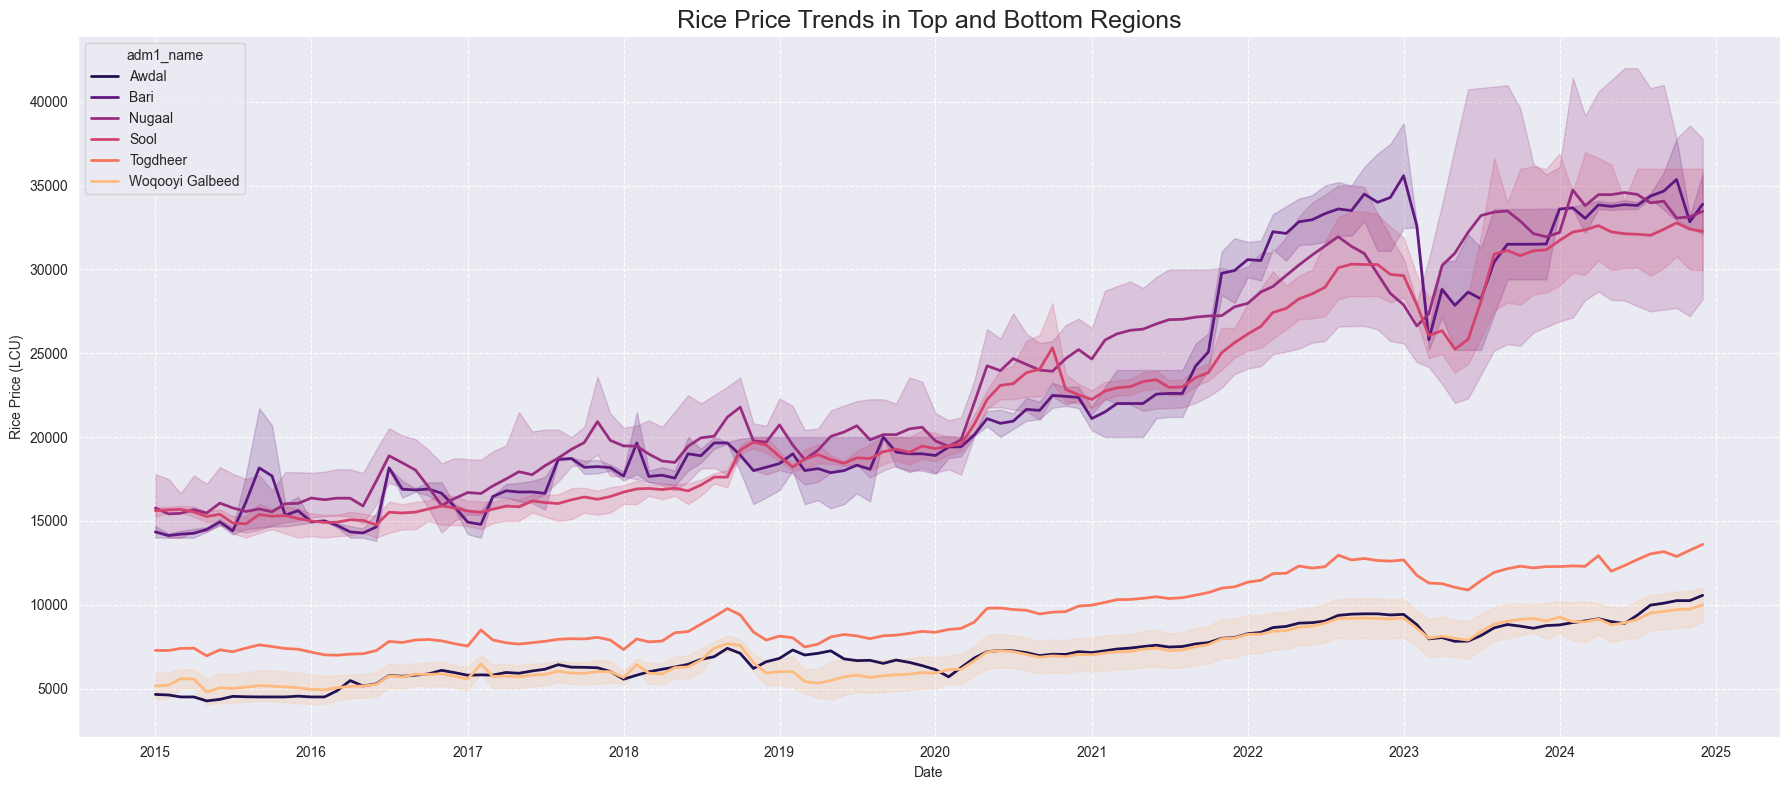

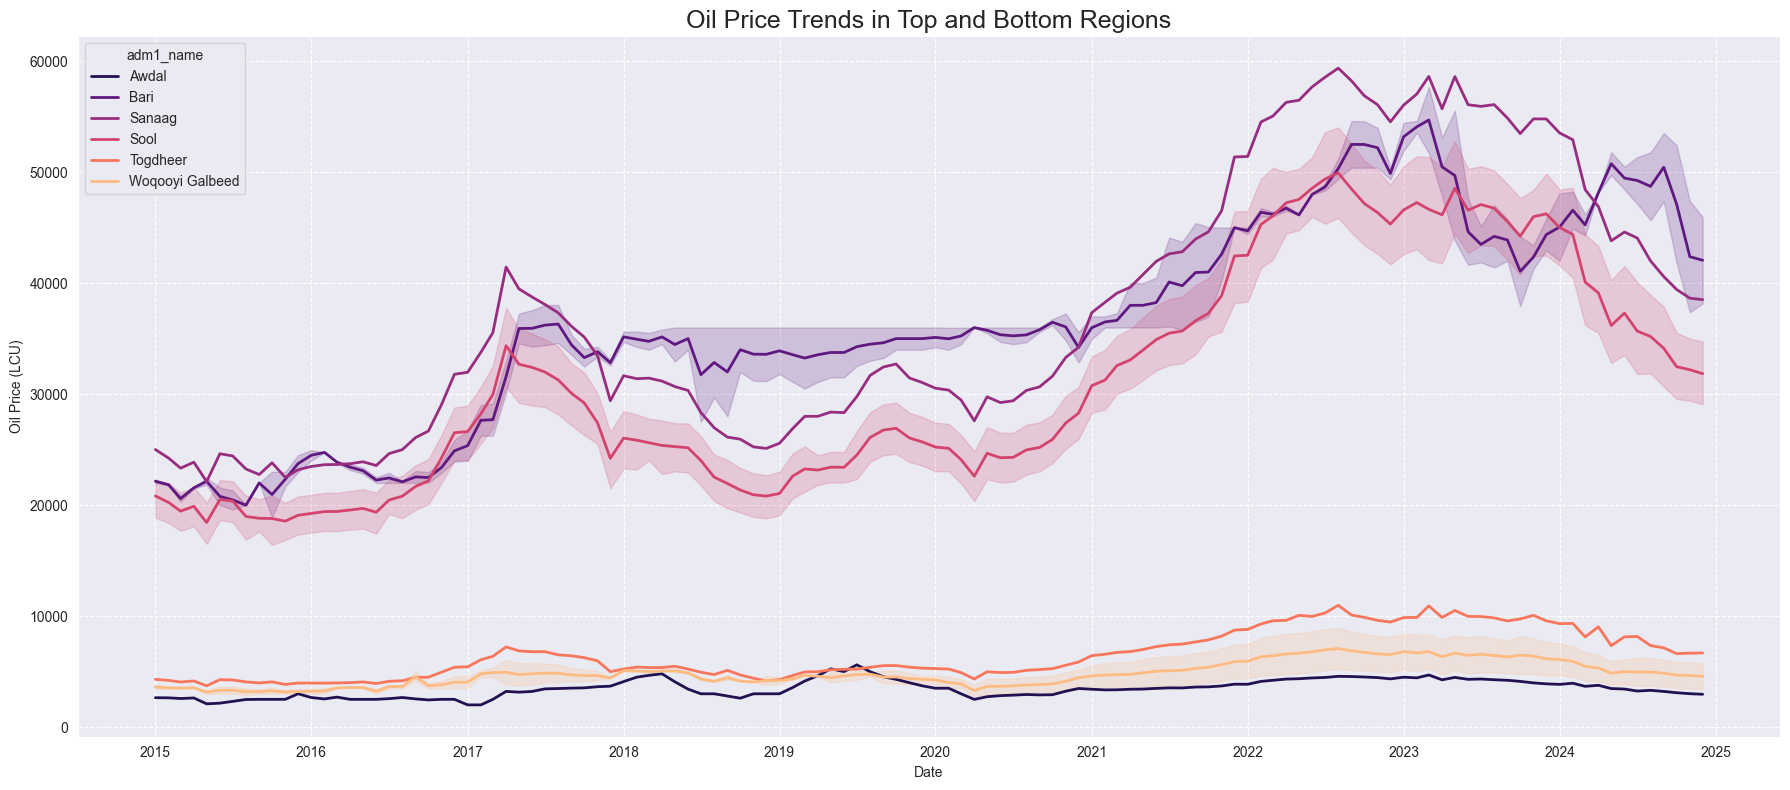

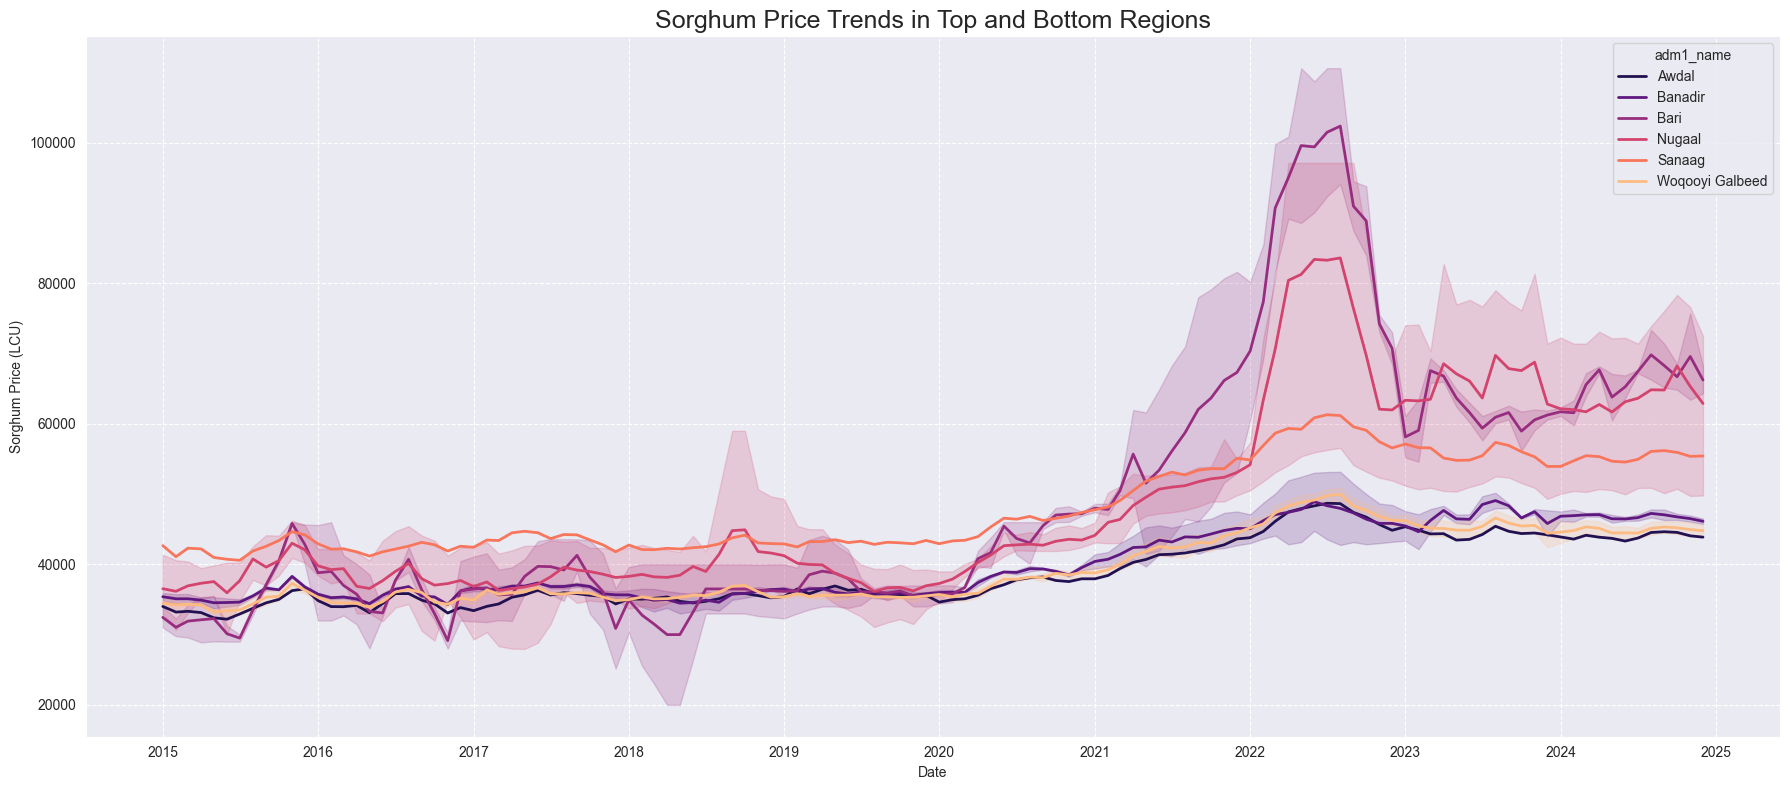

In [71]:
for commodity_name, col in commodities.items():

    region_means = (
        df.groupby('adm1_name')[col]
          .mean()
          .dropna()
          .sort_values()
    )

    bottom_3 = region_means.head(3).index
    top_3 = region_means.tail(3).index

    selected_regions = bottom_3.union(top_3)

    df_subset = df[df['adm1_name'].isin(selected_regions)]

    plt.figure(figsize=(18, 8))

    sns.lineplot(
        data=df_subset,
        x='Date',
        y=col,
        hue='adm1_name',
        palette='magma',
        linewidth=2
    )

    plt.title(
        f"{commodity_name} Price Trends in Top and Bottom Regions",
        fontsize=18
    )
    plt.xlabel("Date")
    plt.ylabel(f"{commodity_name} Price (LCU)")
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()



### Insights from Regional Time Series

*   **Common Trend:** All regions generally follow a similar **upward trend** over the observation period, suggesting macro-economic or national-level factors (like inflation or exchange rate) are dominant drivers.
*   **Co-movement:** There are periods where the price indices of all regions spike simultaneously, likely corresponding to major national shocks (e.g., severe drought years or political instability).


## Feature Engineering
To prepare the data for time series modeling, we will create features that capture temporal dependencies and seasonality.


In [72]:
df['month'] = df.index.month
df['year'] = df.index.year
df['quarter'] = df.index.quarter

for lag in [1, 3, 6]:
    df[f'{TARGET_VARIABLE}_lag_{lag}'] = df.groupby('adm1_name')[TARGET_VARIABLE].shift(lag)

df[f'{TARGET_VARIABLE}_rolling_mean_3'] = df.groupby('adm1_name')[TARGET_VARIABLE].transform(lambda x: x.rolling(window=3).mean())

print("New columns added:")
print(df.columns[-7:].tolist())


New columns added:
['month', 'year', 'quarter', 'food_price_index_lag_1', 'food_price_index_lag_3', 'food_price_index_lag_6', 'food_price_index_rolling_mean_3']


The engineered features are crucial for a robust time series model: 

*   **Time-based features** (month, quarter) will help the model capture recurring seasonal patterns in food prices. 

*   **Lagged features** capture the autocorrelation, allowing the model to predict the current price based on recent past prices in the same region. 

*   **Rolling statistics** provide a smoothed trend, which can help stabilize the model and capture short-term volatility.


The dataset is now cleaned, preprocessed, and enriched with engineered features, making it ready for the modeling phase.


In [ ]:
print("Final Data Structure:")
print(df.head().to_markdown())
print(f"Final Shape: {df.shape}")

print("Remaining Nulls (Expected in Lagged Features):")
print(df.isnull().sum().sort_values(ascending=False).head().to_markdown())


Final Data Structure:
| Date                | adm1_name   | adm2_name   | mkt_name   |   market_price_maize |   market_price_rice |   market_price_sorghum |   market_price_oil |   food_price_index |   population |   climate_temperature |   climate_precipitation |   climate_humidity |   conflict_critical |   conflict_heightened |   conflict_typical |   drought_ndvi_critical |   drought_ndvi_heightened |   drought_ndvi_typical |   drought_rainfall_critical |   drought_rainfall_heightened |   drought_rainfall_typical |   exchange_rate_critical |   exchange_rate_heightened |   exchange_rate_typical |   food_price_critical |   food_price_heightened |   food_price_typical |   fuel_price_critical |   fuel_price_heightened |   fuel_price_typical |   risk_population_estimated |   risk_population_percentage |   heavy_rainfall_critical |   heavy_rainfall_heightened |   heavy_rainfall_typical |   cpi_alcohol_tobacco_narcotics |   cpi_all_groups |   cpi_clothing_footwear |   cpi_communication |   c

In [74]:
df.to_csv("Data/processed_dataset.csv")

## Conclusion

**Data Quality and Feature Characteristics**
- Regional-level imputation was applied to missing population data, ensuring internal consistency.
- Consumption data beyond December 2024 were excluded due to systematic incompleteness, resulting in a reliable training dataset.
- Most price-related features are right-skewed with notable outliers, supporting the use of robust scaling or transformation methods.
- Shock variables (conflict and drought) are empirically relevant but exhibit predominantly non-linear effects.

**Time-Series Structure of the Food Price Index**
- The Food Price Index (FPI) displays a strong, non-stationary upward trend across all regions.
- Despite a shared national trend, substantial regional heterogeneity exists in absolute price levels.
- This pattern indicates the influence of economy-wide inflationary forces alongside localized market dynamics.

**Core Economic and Price Drivers**
- Staple food prices (sorghum, maize, rice, and oil) show the strongest linear relationships with the FPI.
- These commodities emerge as the most immediate and influential supply-side drivers of food price movements.
- The exchange rate exhibits strong co-movement with the FPI, embedding food price inflation within broader macroeconomic dynamics.

**Role of External Shocks**
- Critical-level shocks—particularly fuel and food price crises—are strongly associated with sharp, short-term spikes in the FPI.
- These acute shocks are the primary contributors to volatility in food prices.
- Conflict and drought shocks have more conditional and non-linear effects, shaped by severity, duration, and interactions with prevailing economic conditions.
